# **Guía práctica de Minería de Datos**
## Sistema de alerta temprana de abandono en educación virtual con OULAD

**Entorno:** Google Colab  
**Fuente de datos:** KaggleHub, con respaldo oficial de UCI  
**Alcance práctico:** descarga temporal, inspección, estadística descriptiva, visualización, calidad, preprocesamiento, ingeniería de variables, selección de atributos, PCA, K-Means, comparación de tres clasificadores, validación y exportación.


### Resultado práctico

Al finalizar se genera `paquete_modelo_oulad.zip`, que contiene el modelo, los metadatos de entrada y las versiones necesarias para utilizarlo después en el proyecto de API y página web.

## 1. Definición del problema

### Problema

Las instituciones de educación virtual registran información demográfica, académica y de interacción con sus plataformas, pero no siempre transforman estos registros en señales tempranas que permitan identificar estudiantes con riesgo de abandonar. Cuando el retiro se detecta tarde, disminuye la posibilidad de ofrecer tutorías, recordatorios o acompañamiento oportuno. Este proyecto utilizará información disponible solamente durante los primeros 30 días de cada módulo para construir una alerta temprana reproducible.

### Pregunta de investigación

**¿En qué medida las características demográficas, académicas previas y de interacción durante los primeros 30 días permiten predecir el abandono de estudiantes en educación virtual, y qué perfiles de participación digital pueden identificarse?**

### Unidad de análisis

Una matrícula de un estudiante en un módulo y presentación determinados. La clave compuesta es:

`code_module + code_presentation + id_student`

### Delimitación

- Contexto: cursos virtuales de The Open University.
- Periodo original: 2013-2014.
- Ventana predictiva: días 0 a 29 desde el inicio del módulo.
- Objetivo: `abandono = 1` cuando `final_result == "Withdrawn"`; en otro caso `abandono = 0`.
- Alcance: prototipo académico descriptivo y predictivo; no se realizará una decisión institucional automatizada.

### Variables prohibidas por fuga de información

- `final_result` solo construye la etiqueta y nunca entra como predictor.
- `date_unregistration` revela el retiro y nunca entra como predictor.
- No se utilizarán interacciones ni evaluaciones posteriores al día 29.

## 2. Objetivo general

Desarrollar, evaluar y exportar un modelo de minería de datos que permita identificar tempranamente el riesgo de abandono en estudiantes de educación virtual, utilizando información disponible durante los primeros 30 días en OULAD.

### Objetivos específicos ejecutados en el cuaderno

1. Explorar la estructura, calidad y distribución de los datos mediante estadísticas descriptivas y visualizaciones.
2. Integrar y preprocesar los registros demográficos, académicos y de interacción, generando indicadores correspondientes a los primeros 30 días.
3. Identificar perfiles de participación estudiantil mediante PCA y K-Means.
4. Comparar regresión logística, árbol de decisión y bosque aleatorio mediante validación cruzada y métricas de clasificación.
5. Exportar el modelo seleccionado junto con el preprocesamiento y los metadatos necesarios para su uso externo.

### Elevator pitch

> La educación virtual genera millones de registros sobre acceso a recursos, evaluaciones y participación estudiantil, pero esa información pierde valor si el abandono se detecta cuando ya ocurrió. Este proyecto analizará OULAD, una base pública y anonimizada con datos demográficos, académicos y de interacción en un entorno virtual de aprendizaje. A partir de los primeros 30 días de cada curso se construirán indicadores de actividad, regularidad y desempeño. Se aplicará K-Means para reconocer perfiles de participación y se compararán regresión logística, árbol de decisión y bosque aleatorio para estimar el riesgo de retiro. Los modelos se evaluarán con validación cruzada, precisión, sensibilidad, F1 y ROC-AUC. El resultado permitirá identificar señales tempranas comprensibles y proponer acciones de acompañamiento académico basadas en datos, sin utilizar información que revele anticipadamente el resultado final.

## 3. Metodología aplicada

El proyecto sigue una secuencia basada en **CRISP-DM**, adecuada para organizar un proceso de minería de datos sin mezclar las fases:

1. **Comprensión del problema:** definición del abandono que se desea anticipar.
2. **Comprensión de los datos:** revisión de las siete tablas, estructura, nulos, duplicados y distribuciones.
3. **Preparación de los datos:** integración, limpieza y creación de variables correspondientes a los primeros 30 días.
4. **Modelado:** aplicación de K-Means y comparación de tres clasificadores.
5. **Evaluación:** validación cruzada, conjunto de prueba, métricas e interpretación.
6. **Preparación para el despliegue:** exportación del modelo y sus metadatos para utilizarlos posteriormente en una API y una página web independientes.

## 4. Fuentes verificables y justificación

- Kaggle: https://www.kaggle.com/datasets/vjcalling/ouladdata
- UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset
- Artículo descriptor: https://doi.org/10.1038/sdata.2017.171
- Villar, A., & de Andrade, C. R. V. (2024). *Supervised machine learning algorithms for predicting student dropout and academic success: A comparative study*. https://doi.org/10.1007/s44163-023-00079-z
- Zhidkikh, D., et al. (2024). *Reproducing Predictive Learning Analytics in CS1*. https://doi.org/10.18608/jla.2024.7979

OULAD contiene datos anonimizados y relacionados sobre matrículas, evaluaciones e interacción con un entorno virtual. El artículo original se conserva aunque sea anterior a cinco años porque es la fuente primaria que documenta la creación y anonimización del dataset. Las referencias recientes sustentan la utilidad actual de la predicción temprana, la comparación de modelos y la interpretabilidad.

# Fase 1 — Configuración y obtención de datos

No se usará Google Drive. Los datos originales permanecerán en la caché temporal administrada por `kagglehub`. Las figuras y tablas se conservarán solo durante la sesión para mostrar evidencias; al final únicamente se descargará el paquete del modelo.

In [ ]:
# Instala KaggleHub en la sesión temporal de Colab.
!pip -q install --upgrade kagglehub


In [ ]:
from pathlib import Path                 # Maneja rutas sin depender del sistema operativo.
from IPython.display import display     # Presenta tablas de pandas con formato visual en Colab.
import gc                               # Permite solicitar la liberación de memoria tras procesar bloques.
import importlib.metadata as package_metadata  # Consulta versiones instaladas para reproducibilidad.
import json                             # Guarda metadatos legibles para la futura API.
import platform                         # Informa la versión de Python utilizada.
import warnings                         # Controla advertencias no críticas del entorno.
import zipfile                          # Crea y revisa archivos ZIP.

import joblib                           # Serializa la tubería completa del modelo.
import matplotlib.pyplot as plt         # Construye y guarda figuras.
import numpy as np                      # Realiza operaciones numéricas y vectorizadas.
import pandas as pd                     # Lee, transforma, une y resume tablas.
import seaborn as sns                   # Genera gráficos estadísticos.

from scipy.stats import chi2_contingency, probplot
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    calinski_harabasz_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    davies_bouldin_score,
    f1_score,
    pairwise_distances,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Solo oculta avisos de cambios futuros; los errores y advertencias importantes siguen visibles.
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 100)  # Evita ocultar columnas importantes de las tablas.
pd.set_option('display.max_rows', 100)     # Permite revisar tablas de calidad completas.
sns.set_theme(style='whitegrid', palette='colorblind')  # Paleta legible y apta para daltonismo.

SEMILLA = 42       # Permite reproducir divisiones, muestreos y resultados aleatorios.
VENTANA_DIAS = 30  # Solo utiliza información de los días 0 a 29.

# /content es almacenamiento temporal y se elimina cuando termina la sesión de Colab.
RUTA_TRABAJO = Path('/content/proyecto_oulad')
RUTA_SALIDAS = RUTA_TRABAJO / 'resultados'
RUTA_FIGURAS = RUTA_TRABAJO / 'figuras'
RUTA_EXPORTACION = Path('/content/exportacion_modelo_oulad')

for ruta in [RUTA_SALIDAS, RUTA_FIGURAS, RUTA_EXPORTACION]:
    ruta.mkdir(parents=True, exist_ok=True)  # Crea también las carpetas padre si faltan.

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
import sklearn
print('scikit-learn:', sklearn.__version__)
print('Directorio temporal:', RUTA_TRABAJO)

Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1
Directorio temporal: /content/proyecto_oulad


## 5. Descarga directa con KaggleHub y verificación de integridad

KaggleHub se mantiene como fuente principal y trabaja en el almacenamiento temporal de Colab. Después de la descarga se comprueba que estén presentes los siete CSV originales. Si la caché de Kaggle estuviera incompleta —especialmente por el tamaño de `studentVle.csv`— se recuperarán únicamente los archivos faltantes desde el ZIP oficial de UCI Machine Learning Repository.

No se monta Google Drive, no se suben CSV manualmente y el archivo ZIP temporal de respaldo se elimina después de la extracción.

In [ ]:
import kagglehub

# Descarga la versión más reciente del dataset en la caché temporal de Colab.
path = kagglehub.dataset_download('vjcalling/ouladdata')  # Devuelve la ruta de la caché.
RUTA_DATASET = Path(path)

print('Path to dataset files:', RUTA_DATASET)

100%|██████████| 64.0M/64.0M [00:01<00:00, 62.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vjcalling/ouladdata/versions/1


In [ ]:
ARCHIVOS_ESPERADOS = [
    'courses.csv',
    'assessments.csv',
    'vle.csv',
    'studentInfo.csv',
    'studentRegistration.csv',
    'studentAssessment.csv',
    'studentVle.csv',
]


# Busca el mismo CSV aunque Kaggle lo coloque dentro de una subcarpeta.
def buscar_csv_en_raices(nombre, raices):
    coincidencias = []
    for raiz in raices:
        coincidencias.extend(raiz.rglob(nombre))
    return sorted({ruta.resolve() for ruta in coincidencias})


RAICES_DATOS = [RUTA_DATASET]
faltantes_kaggle = [
    nombre
    for nombre in ARCHIVOS_ESPERADOS
    if not buscar_csv_en_raices(nombre, RAICES_DATOS)
]

print('Archivos faltantes en la descarga de Kaggle:', faltantes_kaggle or 'ninguno')

# Si la copia de Kaggle está incompleta, se recuperan solo los archivos faltantes.
if faltantes_kaggle:
    import shutil
    import urllib.request

    URL_UCI = (
        'https://archive.ics.uci.edu/static/public/349/'
        'open%2Buniversity%2Blearning%2Banalytics%2Bdataset.zip'
    )
    RUTA_UCI = Path('/content/oulad_respaldo_uci')
    RUTA_ZIP_UCI = Path('/content/oulad_uci.zip')
    RUTA_UCI.mkdir(parents=True, exist_ok=True)

    print('La caché de Kaggle está incompleta.')
    print('Descargando el respaldo oficial comprimido de UCI (aprox. 44,6 MB)...')
    urllib.request.urlretrieve(URL_UCI, RUTA_ZIP_UCI)  # Respaldo oficial de UCI.

    # Se inspecciona el ZIP antes de extraer para confirmar que contiene lo requerido.
    with zipfile.ZipFile(RUTA_ZIP_UCI) as archivo_zip:
        miembros = {
            Path(nombre_interno).name: nombre_interno
            for nombre_interno in archivo_zip.namelist()
            if not nombre_interno.endswith('/')
        }

        faltantes_en_uci = [
            nombre for nombre in faltantes_kaggle if nombre not in miembros
        ]
        if faltantes_en_uci:
            raise FileNotFoundError(
                f'El respaldo oficial de UCI tampoco contiene: {faltantes_en_uci}'
            )

        for nombre in faltantes_kaggle:
            destino = RUTA_UCI / nombre
            print(f'Extrayendo desde UCI: {nombre}')
            with archivo_zip.open(miembros[nombre]) as origen, destino.open('wb') as salida:
                # Copia en bloques de 1 MB y evita cargar studentVle completo en RAM.
                shutil.copyfileobj(origen, salida, length=1024 * 1024)

    RUTA_ZIP_UCI.unlink(missing_ok=True)  # Borra únicamente el ZIP temporal.
    RAICES_DATOS.append(RUTA_UCI)
    print('Respaldo completado y ZIP temporal eliminado.')


# Exige una sola copia para no leer por accidente una versión equivocada.
def localizar_csv(nombre):
    coincidencias = buscar_csv_en_raices(nombre, RAICES_DATOS)
    if len(coincidencias) != 1:
        raise FileNotFoundError(
            f'Se esperaba exactamente un archivo {nombre}, encontrados: {coincidencias}'
        )
    return coincidencias[0]


ARCHIVOS = {
    nombre: localizar_csv(nombre)
    for nombre in ARCHIVOS_ESPERADOS
}

inventario_archivos = pd.DataFrame([
    {
        'archivo': nombre,
        'tamano_mb': round(ruta.stat().st_size / 1024**2, 2),
        'fuente': 'Kaggle' if str(ruta).startswith(str(RUTA_DATASET.resolve())) else 'UCI',
        'ruta_temporal': str(ruta),
    }
    for nombre, ruta in ARCHIVOS.items()
]).sort_values('archivo')

display(inventario_archivos)

assert set(ARCHIVOS) == set(ARCHIVOS_ESPERADOS)  # Comprueba los siete nombres.
assert all(ruta.is_file() and ruta.stat().st_size > 0 for ruta in ARCHIVOS.values())  # Evita archivos vacíos.

print('Validación correcta: se encontraron los siete CSV originales de OULAD.')


Archivos faltantes en la descarga de Kaggle: ['studentVle.csv']
La caché de Kaggle está incompleta.
Descargando el respaldo oficial comprimido de UCI (aprox. 44,6 MB)...
Extrayendo desde UCI: studentVle.csv
Respaldo completado y ZIP temporal eliminado.


,archivo,tamano_mb,fuente,ruta_temporal
1,assessments.csv,0.01,Kaggle,/root/.cache/kagglehub/datasets/vjcalling/oula...
0,courses.csv,0.00,Kaggle,/root/.cache/kagglehub/datasets/vjcalling/oula...
5,studentAssessment.csv,5.43,Kaggle,/root/.cache/kagglehub/datasets/vjcalling/oula...
3,studentInfo.csv,3.30,Kaggle,/root/.cache/kagglehub/datasets/vjcalling/oula...
4,studentRegistration.csv,1.06,Kaggle,/root/.cache/kagglehub/datasets/vjcalling/oula...
6,studentVle.csv,432.81,UCI,/content/oulad_respaldo_uci/studentVle.csv
2,vle.csv,0.25,Kaggle,/root/.cache/kagglehub/datasets/vjcalling/oula...


Validación correcta: se encontraron los siete CSV originales de OULAD.


## 6. Relación entre las tablas

```text
courses ────────────┬──────── studentInfo ───── studentRegistration
                    │               │
                    │               ├────────── studentVle ───── vle
                    │               │
                    └──────── assessments ───── studentAssessment
```

- `code_module` y `code_presentation` identifican el módulo y su presentación.
- `id_student` identifica al estudiante de forma anonimizada.
- `id_assessment` relaciona evaluaciones con resultados.
- `id_site` relaciona recursos virtuales con interacciones.

La tabla `studentVle.csv` es muy grande. Se procesará por bloques para mantener estable la memoria de Colab.

In [ ]:
# Estas seis tablas caben completas en memoria y se cargan con pandas.
courses = pd.read_csv(ARCHIVOS['courses.csv'])
assessments = pd.read_csv(ARCHIVOS['assessments.csv'])
vle = pd.read_csv(ARCHIVOS['vle.csv'])
student_info_raw = pd.read_csv(ARCHIVOS['studentInfo.csv'])
student_registration = pd.read_csv(ARCHIVOS['studentRegistration.csv'])
student_assessment = pd.read_csv(ARCHIVOS['studentAssessment.csv'])

# studentVle supera los diez millones de filas; aquí solo se verifica su estructura.
student_vle_muestra = pd.read_csv(ARCHIVOS['studentVle.csv'], nrows=10)

tablas_cargadas = {
    'courses': courses,
    'assessments': assessments,
    'vle': vle,
    'studentInfo': student_info_raw,
    'studentRegistration': student_registration,
    'studentAssessment': student_assessment,
}

# shape[0] devuelve filas y shape[1] devuelve columnas.
resumen_tablas = pd.DataFrame([
    {'tabla': nombre, 'filas': df.shape[0], 'columnas': df.shape[1]}
    for nombre, df in tablas_cargadas.items()
])
display(resumen_tablas)
display(student_vle_muestra)

,tabla,filas,columnas
0,courses,22,3
1,assessments,206,6
2,vle,6364,6
3,studentInfo,32593,12
4,studentRegistration,32593,5
5,studentAssessment,173912,5


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1
5,AAA,2013J,28400,546652,-10,8
6,AAA,2013J,28400,546876,-10,2
7,AAA,2013J,28400,546688,-10,15
8,AAA,2013J,28400,546662,-10,17
9,AAA,2013J,28400,546890,-10,1


# Fase 2 — Comprensión y calidad de los datos

In [ ]:
# Una matrícula se identifica por estudiante, módulo y presentación; id_student solo no basta.
CLAVE = ['code_module', 'code_presentation', 'id_student']

duplicados_exactos_raw = int(student_info_raw.duplicated().sum())  # Filas idénticas completas.
porcentaje_duplicados_raw = round(duplicados_exactos_raw / len(student_info_raw) * 100, 4)

student_info = student_info_raw.drop_duplicates().copy()  # Conserva una copia sin duplicados exactos.
duplicados_clave = int(student_info.duplicated(subset=CLAVE).sum())  # Detecta claves repetidas con otros datos.

calidad_student_info = pd.DataFrame({
    'tipo': student_info.dtypes.astype(str),
    'nulos': student_info.isna().sum(),
    'porcentaje_nulos': (student_info.isna().mean() * 100).round(2),
    'valores_unicos': student_info.nunique(dropna=False),
}).sort_values('porcentaje_nulos', ascending=False)

print(f'Duplicados exactos: {duplicados_exactos_raw} ({porcentaje_duplicados_raw} %)')
print(f'Duplicados según clave compuesta después de consolidar exactos: {duplicados_clave}')
display(calidad_student_info)

# Una clave repetida podría multiplicar filas al unir las tablas.
if duplicados_clave:
    raise ValueError('Existen claves repetidas no explicadas. Deben revisarse antes de integrar.')

Duplicados exactos: 0 (0.0 %)
Duplicados según clave compuesta después de consolidar exactos: 0


,tipo,nulos,porcentaje_nulos,valores_unicos
imd_band,object,1111,3.41,11
code_module,object,0,0.00,7
id_student,int64,0,0.00,28785
code_presentation,object,0,0.00,4
gender,object,0,0.00,2
region,object,0,0.00,13
highest_education,object,0,0.00,5
age_band,object,0,0.00,3
num_of_prev_attempts,int64,0,0.00,7
studied_credits,int64,0,0.00,61


In [ ]:
student_info.info()  # Muestra tipos, columnas, memoria y cantidad de valores no nulos.
display(student_info.head())
display(student_info.describe(include='all').T)  # Resume variables numéricas y categóricas. ##Revisar

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code_module,32593,7,BBB,7909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_presentation,32593,4,2014J,11260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_student,32593.0,NaN,NaN,NaN,706687.669131,549167.313855,3733.0,508573.0,590310.0,644453.0,2716795.0
gender,32593,2,M,17875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,32593,13,Scotland,3446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
highest_education,32593,5,A Level or Equivalent,14045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imd_band,31482,10,20-30%,3654,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_band,32593,3,0-35,22944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_of_prev_attempts,32593.0,NaN,NaN,NaN,0.163225,0.479758,0.0,0.0,0.0,0.0,6.0
studied_credits,32593.0,NaN,NaN,NaN,79.758691,41.0719,30.0,60.0,60.0,120.0,655.0


,abandono,cantidad,porcentaje
0,0,22437,68.84
1,1,10156,31.16


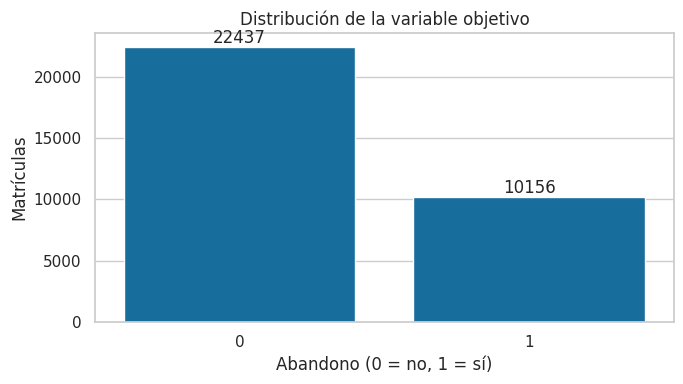

In [ ]:
# 1 = Withdrawn; 0 = Pass, Fail o Distinction. final_result no se usará como predictor.
student_info['abandono'] = student_info['final_result'].eq('Withdrawn').astype('int8')

distribucion_objetivo = (
    student_info['abandono']
    .value_counts()
    .rename_axis('abandono')
    .reset_index(name='cantidad')
)
distribucion_objetivo['porcentaje'] = (
    distribucion_objetivo['cantidad'] / len(student_info) * 100
).round(2)

display(distribucion_objetivo)

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=student_info, x='abandono')
ax.set(
    title='Distribución de la variable objetivo',
    xlabel='Abandono (0 = no, 1 = sí)',
    ylabel='Matrículas',
)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '01_distribucion_objetivo.png', dpi=180, bbox_inches='tight')
plt.show()

# Fase 3 — Preparación e integración

## 7. Interacciones de los primeros 30 días

Para evitar fuga temporal se conservan solamente los registros con `0 <= date < 30`. El procesamiento por bloques evita cargar los más de diez millones de registros simultáneamente.

In [ ]:
# Tipos compactos para reducir el uso de memoria al leer la tabla más grande.
DTYPES_VLE = {
    'code_module': 'category',
    'code_presentation': 'category',
    'id_student': 'int32',
    'id_site': 'int32',
    'date': 'int16',
    'sum_click': 'int32',
}

partes_clicks = []
partes_dias = []
partes_recursos = []
filas_totales_vle = 0
filas_ventana_vle = 0

for numero_bloque, bloque in enumerate(
    pd.read_csv(
        ARCHIVOS['studentVle.csv'],
        chunksize=750_000,  # Lee por bloques; no carga las 10,6 millones de filas a la vez.
        dtype=DTYPES_VLE,
    ),
    start=1,
):
    filas_totales_vle += len(bloque)
    # Conserva únicamente la actividad desde el día 0 hasta el día 29.
    ventana = bloque.loc[
        bloque['date'].ge(0) & bloque['date'].lt(VENTANA_DIAS),
        CLAVE + ['id_site', 'date', 'sum_click'],
    ].copy()
    filas_ventana_vle += len(ventana)

    if not ventana.empty:
        partes_clicks.append(
            # observed=True evita crear combinaciones categóricas que no existen.
            ventana.groupby(CLAVE, observed=True, as_index=False)['sum_click'].sum()
        )
        partes_dias.append(ventana[CLAVE + ['date']].drop_duplicates())  # Un día cuenta una sola vez. ##Reviar cuantos duplicados se borrar
        partes_recursos.append(ventana[CLAVE + ['id_site']].drop_duplicates())  # Un recurso cuenta una sola vez.

    print(
        f'Bloque {numero_bloque:02d} | filas acumuladas: {filas_totales_vle:,} | '
        f'filas en ventana: {filas_ventana_vle:,}'
    )

clicks_30 = (
    pd.concat(partes_clicks, ignore_index=True)
    .groupby(CLAVE, observed=True, as_index=False)['sum_click']
    .sum()
    .rename(columns={'sum_click': 'clicks_30_dias'})
)

dias_activos_30 = (
    pd.concat(partes_dias, ignore_index=True)
    .drop_duplicates()
    .groupby(CLAVE, observed=True, as_index=False)
    .size()
    .rename(columns={'size': 'dias_activos_30'})
)

recursos_30 = (
    pd.concat(partes_recursos, ignore_index=True)
    .drop_duplicates()
    .groupby(CLAVE, observed=True, as_index=False)
    .size()
    .rename(columns={'size': 'recursos_distintos_30'})
)

vle_30 = (
    clicks_30
    .merge(dias_activos_30, on=CLAVE, how='outer', validate='one_to_one')  # Impide multiplicar matrículas.
    .merge(recursos_30, on=CLAVE, how='outer', validate='one_to_one')
)

for columna in ['code_module', 'code_presentation']:
    vle_30[columna] = vle_30[columna].astype(str)

display(vle_30.head())
print('Matrículas con actividad durante la ventana:', len(vle_30))

del partes_clicks, partes_dias, partes_recursos, clicks_30, dias_activos_30, recursos_30
gc.collect()  # Solicita liberar la memoria de los bloques ya resumidos.

Bloque 01 | filas acumuladas: 750,000 | filas en ventana: 161,398
Bloque 02 | filas acumuladas: 1,500,000 | filas en ventana: 304,971
Bloque 03 | filas acumuladas: 2,250,000 | filas en ventana: 508,011
Bloque 04 | filas acumuladas: 3,000,000 | filas en ventana: 659,238
Bloque 05 | filas acumuladas: 3,750,000 | filas en ventana: 813,965
Bloque 06 | filas acumuladas: 4,500,000 | filas en ventana: 1,018,238
Bloque 07 | filas acumuladas: 5,250,000 | filas en ventana: 1,129,563
Bloque 08 | filas acumuladas: 6,000,000 | filas en ventana: 1,318,344
Bloque 09 | filas acumuladas: 6,750,000 | filas en ventana: 1,515,648
Bloque 10 | filas acumuladas: 7,500,000 | filas en ventana: 1,740,366
Bloque 11 | filas acumuladas: 8,250,000 | filas en ventana: 1,766,448
Bloque 12 | filas acumuladas: 9,000,000 | filas en ventana: 1,918,862
Bloque 13 | filas acumuladas: 9,750,000 | filas en ventana: 2,168,180
Bloque 14 | filas acumuladas: 10,500,000 | filas en ventana: 2,198,896
Bloque 15 | filas acumuladas: 1

,code_module,code_presentation,id_student,clicks_30_dias,dias_activos_30,recursos_distintos_30
0,AAA,2013J,11391,321,8,26
1,AAA,2013J,28400,403,12,25
2,AAA,2013J,30268,179,6,17
3,AAA,2013J,31604,334,18,22
4,AAA,2013J,32885,272,16,18


Matrículas con actividad durante la ventana: 27938


169

## 8. Evaluaciones de los primeros 30 días

Se excluyen resultados transferidos de presentaciones anteriores (`is_banked = 1`) y se conservan entregas realizadas durante la ventana temprana.

In [ ]:
evaluaciones_detalle = student_assessment.merge(
    assessments[
        ['id_assessment', 'code_module', 'code_presentation', 'assessment_type', 'date', 'weight']
    ],
    on='id_assessment',
    how='left',
    validate='many_to_one',  # Cada id_assessment debe tener un solo registro descriptivo.
)

# is_banked=1 corresponde a una nota transferida desde un intento anterior.
evaluaciones_ventana = evaluaciones_detalle.loc[
    evaluaciones_detalle['date_submitted'].ge(0)
    & evaluaciones_detalle['date_submitted'].lt(VENTANA_DIAS)
    & evaluaciones_detalle['is_banked'].eq(0)
].copy()

evaluaciones_ventana['aprobada'] = evaluaciones_ventana['score'].ge(40).astype('int8')  # OULAD usa 40 como nota mínima.
evaluaciones_ventana['entrega_tardia'] = (
    evaluaciones_ventana['date'].notna()
    & evaluaciones_ventana['date_submitted'].gt(evaluaciones_ventana['date'])  # Entrega posterior a la fecha prevista.
).astype('int8')

assessment_30 = (
    evaluaciones_ventana
    .groupby(CLAVE, as_index=False)
    .agg(
        evaluaciones_30=('id_assessment', 'count'),
        nota_promedio_30=('score', 'mean'),
        proporcion_aprobadas_30=('aprobada', 'mean'),
        entregas_tardias_30=('entrega_tardia', 'sum'),
    )
)

display(assessment_30.head())
print('Matrículas con evaluaciones en la ventana:', len(assessment_30))

,code_module,code_presentation,id_student,evaluaciones_30,nota_promedio_30,proporcion_aprobadas_30,entregas_tardias_30
0,AAA,2013J,11391,1,78.0,1.0,0
1,AAA,2013J,28400,1,70.0,1.0,1
2,AAA,2013J,31604,1,72.0,1.0,0
3,AAA,2013J,32885,1,69.0,1.0,1
4,AAA,2013J,38053,1,79.0,1.0,0


Matrículas con evaluaciones en la ventana: 20438


## 9. Integración de la unidad de análisis

Se parte de `studentInfo`, se incorpora la fecha de registro y después los agregados de interacción y evaluación. Cada unión se valida como uno a uno para impedir duplicaciones accidentales.

In [ ]:
duplicados_registro_exactos = int(student_registration.duplicated().sum())
porcentaje_registro_exactos = round(
    duplicados_registro_exactos / len(student_registration) * 100,
    4,
)
registro_unico = student_registration.drop_duplicates().copy()  # Elimina solo filas idénticas.
duplicados_registro_clave = int(registro_unico.duplicated(subset=CLAVE).sum())

print(
    'Duplicados exactos en studentRegistration:',
    f'{duplicados_registro_exactos} ({porcentaje_registro_exactos} %)'
)
print('Duplicados no exactos por clave en studentRegistration:', duplicados_registro_clave)

# Una clave repetida con valores diferentes debe investigarse, no eliminarse automáticamente.
if duplicados_registro_clave:
    raise ValueError('studentRegistration contiene claves duplicadas con valores diferentes.')

base = (
    student_info
    .merge(
        registro_unico[CLAVE + ['date_registration']],
        on=CLAVE,
        how='left',
        validate='one_to_one',  # Verifica una sola fila de registro por matrícula.
    )
    .merge(vle_30, on=CLAVE, how='left', validate='one_to_one')  # Conserva todas las matrículas.
    .merge(assessment_30, on=CLAVE, how='left', validate='one_to_one')
)

columnas_cero = [
    'clicks_30_dias',
    'dias_activos_30',
    'recursos_distintos_30',
    'evaluaciones_30',
    'proporcion_aprobadas_30',
    'entregas_tardias_30',
]

# La ausencia de interacción o entrega representa cero; una nota inexistente no equivale a cero.
base[columnas_cero] = base[columnas_cero].fillna(0)

for columna in [
    'clicks_30_dias', 'dias_activos_30', 'recursos_distintos_30',
    'evaluaciones_30', 'entregas_tardias_30'
]:
    base[columna] = base[columna].astype('int32')  # Reduce memoria sin perder enteros.

duplicados_base_exactos = int(base.duplicated().sum())
porcentaje_base_exactos = round(duplicados_base_exactos / len(base) * 100, 4)
duplicados_base_clave = int(base.duplicated(subset=CLAVE).sum())
porcentaje_base_clave = round(duplicados_base_clave / len(base) * 100, 4)

print('Forma de la base integrada:', base.shape)
print('Duplicados exactos:', f'{duplicados_base_exactos} ({porcentaje_base_exactos} %)')
print('Duplicados por clave:', f'{duplicados_base_clave} ({porcentaje_base_clave} %)')

assert len(base) >= 1000, 'Se requieren al menos 1000 registros.'
assert base.shape[1] >= 5, 'Se requieren al menos 5 variables.'
assert not base.duplicated(subset=CLAVE).any(), 'La integración generó claves repetidas.'

Duplicados exactos en studentRegistration: 0 (0.0 %)
Duplicados no exactos por clave en studentRegistration: 0
Forma de la base integrada: (32593, 21)
Duplicados exactos: 0 (0.0 %)
Duplicados por clave: 0 (0.0 %)


## 10. Ingeniería de características

Las variables siguientes se construyen sin información posterior al día 29:

- actividad total y regularidad;
- diversidad de recursos;
- desempeño temprano;
- razones normalizadas para comparar estudiantes con distintas intensidades de uso;
- transformaciones logarítmicas para reducir la influencia de distribuciones muy asimétricas.

In [ ]:
# En OULAD las fechas previas al inicio son negativas; se cambia el signo para interpretarlas como anticipación.
base['dias_anticipacion_registro'] = -base['date_registration']

# np.divide con where evita dividir entre cero cuando el estudiante no tuvo días activos.
base['clicks_promedio_dia_activo_30'] = np.divide(
    base['clicks_30_dias'],
    base['dias_activos_30'],
    out=np.zeros(len(base), dtype=float),
    where=base['dias_activos_30'].gt(0),
)

base['tasa_dias_activos_30'] = base['dias_activos_30'] / VENTANA_DIAS

# Se aplica el mismo control cuando no se consultó ningún recurso.
base['clicks_por_recurso_30'] = np.divide(
    base['clicks_30_dias'],
    base['recursos_distintos_30'],
    out=np.zeros(len(base), dtype=float),
    where=base['recursos_distintos_30'].gt(0),
)

base['sin_evaluaciones_30'] = base['evaluaciones_30'].eq(0).astype('int8')
base['log_clicks_30'] = np.log1p(base['clicks_30_dias'])  # log1p acepta cero y reduce la asimetría. ##Que se aplico??
base['log_recursos_30'] = np.log1p(base['recursos_distintos_30'])  # Conserva el valor cero.

variables_derivadas = [
    'dias_anticipacion_registro',
    'clicks_promedio_dia_activo_30',
    'tasa_dias_activos_30',
    'clicks_por_recurso_30',
    'sin_evaluaciones_30',
    'log_clicks_30',
    'log_recursos_30',
]

display(base[CLAVE + variables_derivadas].head())
print('Variables derivadas creadas:', len(variables_derivadas))

,code_module,code_presentation,id_student,dias_anticipacion_registro,clicks_promedio_dia_activo_30,tasa_dias_activos_30,clicks_por_recurso_30,sin_evaluaciones_30,log_clicks_30,log_recursos_30
0,AAA,2013J,11391,159.0,40.125000,0.266667,12.346154,0,5.774552,3.295837
1,AAA,2013J,28400,53.0,33.583333,0.400000,16.120000,0,6.001415,3.258097
2,AAA,2013J,30268,92.0,29.833333,0.200000,10.529412,1,5.192957,2.890372
3,AAA,2013J,31604,52.0,18.555556,0.600000,15.181818,0,5.814131,3.135494
4,AAA,2013J,32885,176.0,17.000000,0.533333,15.111111,0,5.609472,2.944439


Variables derivadas creadas: 7


In [ ]:
# La columna "uso" indica si una variable entra al modelo, sirve para auditoría o está prohibida.
diccionario = pd.DataFrame([
    ['code_module', 'Categórica', 'Código anonimizado del módulo', 'Predictora'],
    ['code_presentation', 'Categórica', 'Presentación del módulo', 'Predictora'],
    ['id_student', 'Identificador', 'Código anonimizado del estudiante', 'Solo clave'],
    ['gender', 'Categórica', 'Género registrado', 'Auditoría; no predictora'],
    ['region', 'Categórica', 'Región generalizada', 'EDA; no predictora'],
    ['highest_education', 'Categórica ordinal', 'Mayor educación previa', 'Predictora'],
    ['imd_band', 'Categórica ordinal', 'Banda del índice de privación', 'Auditoría; no predictora'],
    ['age_band', 'Categórica ordinal', 'Rango de edad', 'Predictora'],
    ['num_of_prev_attempts', 'Numérica', 'Intentos previos en el módulo', 'Predictora'],
    ['studied_credits', 'Numérica', 'Créditos cursados', 'Predictora'],
    ['disability', 'Categórica', 'Discapacidad declarada', 'Auditoría; no predictora'],
    ['date_registration', 'Numérica', 'Día relativo del registro original', 'Origen de variable derivada'],
    ['date_unregistration', 'Numérica', 'Día de retiro', 'Prohibida por fuga'],
    ['dias_anticipacion_registro', 'Numérica derivada', 'Días de anticipación del registro', 'Predictora'],
    ['clicks_30_dias', 'Numérica derivada', 'Clics durante días 0-29', 'Predictora'],
    ['dias_activos_30', 'Numérica derivada', 'Días con actividad durante días 0-29', 'Predictora'],
    ['recursos_distintos_30', 'Numérica derivada', 'Recursos distintos consultados', 'Predictora'],
    ['evaluaciones_30', 'Numérica derivada', 'Evaluaciones entregadas en días 0-29', 'Predictora'],
    ['nota_promedio_30', 'Numérica derivada', 'Promedio temprano; nulo si no entregó', 'Predictora'],
    ['proporcion_aprobadas_30', 'Numérica derivada', 'Proporción de evaluaciones aprobadas', 'Predictora'],
    ['entregas_tardias_30', 'Numérica derivada', 'Entregas tardías en días 0-29', 'Predictora'],
    ['clicks_promedio_dia_activo_30', 'Numérica derivada', 'Intensidad por día activo', 'EDA/clustering'],
    ['tasa_dias_activos_30', 'Numérica derivada', 'Proporción de días activos', 'EDA/clustering'],
    ['clicks_por_recurso_30', 'Numérica derivada', 'Intensidad por recurso', 'EDA'],
    ['sin_evaluaciones_30', 'Binaria derivada', '1 si no entregó evaluaciones', 'EDA/selección'],
    ['log_clicks_30', 'Numérica derivada', 'log(1 + clics)', 'EDA/clustering'],
    ['log_recursos_30', 'Numérica derivada', 'log(1 + recursos)', 'EDA/clustering'],
    ['final_result', 'Categórica', 'Resultado final', 'Solo crea el objetivo'],
    ['abandono', 'Binaria', '1 Withdrawn; 0 otro resultado', 'Objetivo'],
], columns=['variable', 'tipo', 'descripcion', 'uso'])

display(diccionario)

,variable,tipo,descripcion,uso
0,code_module,Categórica,Código anonimizado del módulo,Predictora
1,code_presentation,Categórica,Presentación del módulo,Predictora
2,id_student,Identificador,Código anonimizado del estudiante,Solo clave
3,gender,Categórica,Género registrado,Auditoría; no predictora
4,region,Categórica,Región generalizada,EDA; no predictora
5,highest_education,Categórica ordinal,Mayor educación previa,Predictora
6,imd_band,Categórica ordinal,Banda del índice de privación,Auditoría; no predictora
7,age_band,Categórica ordinal,Rango de edad,Predictora
8,num_of_prev_attempts,Numérica,Intentos previos en el módulo,Predictora
9,studied_credits,Numérica,Créditos cursados,Predictora


# Fase 4 — Análisis exploratorio completo

In [ ]:
calidad_base = pd.DataFrame({
    'tipo': base.dtypes.astype(str),
    'nulos': base.isna().sum(),
    'porcentaje_nulos': (base.isna().mean() * 100).round(2),  # mean de booleanos = proporción de nulos.
    'unicos': base.nunique(dropna=False),
}).sort_values('porcentaje_nulos', ascending=False)

display(calidad_base)

variables_numericas_eda = [
    'num_of_prev_attempts', 'studied_credits', 'dias_anticipacion_registro',
    'clicks_30_dias', 'dias_activos_30', 'recursos_distintos_30',
    'evaluaciones_30', 'nota_promedio_30', 'proporcion_aprobadas_30',
    'clicks_promedio_dia_activo_30', 'tasa_dias_activos_30',
    'clicks_por_recurso_30',
]

display(base[variables_numericas_eda].describe().T.round(3))  # Media, dispersión, cuartiles y extremos.

,tipo,nulos,porcentaje_nulos,unicos
nota_promedio_30,float64,12167,37.33,230
imd_band,object,1111,3.41,11
date_registration,float64,45,0.14,333
dias_anticipacion_registro,float64,45,0.14,333
gender,object,0,0.00,2
region,object,0,0.00,13
highest_education,object,0,0.00,5
age_band,object,0,0.00,3
num_of_prev_attempts,int64,0,0.00,7
code_module,object,0,0.00,7


,count,mean,std,min,25%,50%,75%,max
num_of_prev_attempts,32593.0,0.163,0.480,0.0,0.000,0.000,0.000,6.000
studied_credits,32593.0,79.759,41.072,30.0,60.000,60.000,120.000,655.000
dias_anticipacion_registro,32548.0,69.411,49.261,-167.0,29.000,57.000,100.000,322.000
clicks_30_dias,32593.0,250.500,334.648,0.0,33.000,144.000,342.000,6440.000
dias_activos_30,32593.0,9.804,7.977,0.0,3.000,8.000,15.000,30.000
recursos_distintos_30,32593.0,20.936,18.222,0.0,7.000,17.000,30.000,263.000
evaluaciones_30,32593.0,0.732,0.662,0.0,0.000,1.000,1.000,4.000
nota_promedio_30,20426.0,72.917,21.954,0.0,65.000,78.000,88.000,100.000
proporcion_aprobadas_30,32593.0,0.582,0.492,0.0,0.000,1.000,1.000,1.000
clicks_promedio_dia_activo_30,32593.0,18.986,16.344,0.0,7.923,16.188,26.786,260.947


In [ ]:
# mode() puede devolver varias modas; se usa la primera únicamente para resumir.
modas = base[variables_numericas_eda].mode(dropna=True)
primera_moda = modas.iloc[0] if not modas.empty else pd.Series(dtype=float)

estadisticas_ampliadas = pd.DataFrame({
    'conteo': base[variables_numericas_eda].count(),
    'media': base[variables_numericas_eda].mean(),
    'mediana': base[variables_numericas_eda].median(),
    'moda': primera_moda,
    'varianza': base[variables_numericas_eda].var(),
    'desviacion_estandar': base[variables_numericas_eda].std(),
    'minimo': base[variables_numericas_eda].min(),
    'q1': base[variables_numericas_eda].quantile(0.25),
    'q3': base[variables_numericas_eda].quantile(0.75),
    'maximo': base[variables_numericas_eda].max(),
    'asimetria': base[variables_numericas_eda].skew(),
    'curtosis': base[variables_numericas_eda].kurt(),
}).round(3)

display(estadisticas_ampliadas)

# Esta tabla documenta por qué no todos los nulos reciben el mismo tratamiento.
tratamiento_nulos = pd.DataFrame([
    ['Actividad y entregas ausentes', 'Rellenar con 0', 'La ausencia representa que no hubo actividad.'],
    ['nota_promedio_30', 'Mediana + indicador', 'No entregar no equivale a obtener nota cero.'],
    ['Variables numéricas restantes', 'Mediana + indicador', 'Tratamiento robusto aprendido solo con entrenamiento.'],
    ['Variables categóricas', 'Categoría Unknown', 'Conserva la ausencia sin inventar una categoría real.'],
], columns=['grupo_o_variable', 'tratamiento', 'justificacion'])

display(tratamiento_nulos)

# Los CSV se guardan solo en /content como evidencia temporal; no se usa Google Drive.
estadisticas_ampliadas.to_csv(RUTA_SALIDAS / 'estadisticas_ampliadas.csv')
calidad_base.to_csv(RUTA_SALIDAS / 'calidad_base.csv')

,conteo,media,mediana,moda,varianza,desviacion_estandar,minimo,q1,q3,maximo,asimetria,curtosis
num_of_prev_attempts,32593,0.163,0.000,0.0,0.230,0.480,0.0,0.000,0.000,6.000,3.808,19.432
studied_credits,32593,79.759,60.000,60.0,1686.901,41.072,30.0,60.000,120.000,655.000,1.876,7.738
dias_anticipacion_registro,32548,69.411,57.000,22.0,2426.599,49.261,-167.0,29.000,100.000,322.000,1.008,1.002
clicks_30_dias,32593,250.500,144.000,0.0,111989.077,334.648,0.0,33.000,342.000,6440.000,3.522,24.560
dias_activos_30,32593,9.804,8.000,0.0,63.627,7.977,0.0,3.000,15.000,30.000,0.618,-0.521
recursos_distintos_30,32593,20.936,17.000,0.0,332.054,18.222,0.0,7.000,30.000,263.000,1.187,2.377
evaluaciones_30,32593,0.732,1.000,1.0,0.438,0.662,0.0,0.000,1.000,4.000,0.686,0.769
nota_promedio_30,20426,72.917,78.000,100.0,481.960,21.954,0.0,65.000,88.000,100.000,-1.533,2.674
proporcion_aprobadas_30,32593,0.582,1.000,1.0,0.242,0.492,0.0,0.000,1.000,1.000,-0.334,-1.885
clicks_promedio_dia_activo_30,32593,18.986,16.188,0.0,267.136,16.344,0.0,7.923,26.786,260.947,1.862,8.906


,grupo_o_variable,tratamiento,justificacion
0,Actividad y entregas ausentes,Rellenar con 0,La ausencia representa que no hubo actividad.
1,nota_promedio_30,Mediana + indicador,No entregar no equivale a obtener nota cero.
2,Variables numéricas restantes,Mediana + indicador,Tratamiento robusto aprendido solo con entrena...
3,Variables categóricas,Categoría Unknown,Conserva la ausencia sin inventar una categorí...


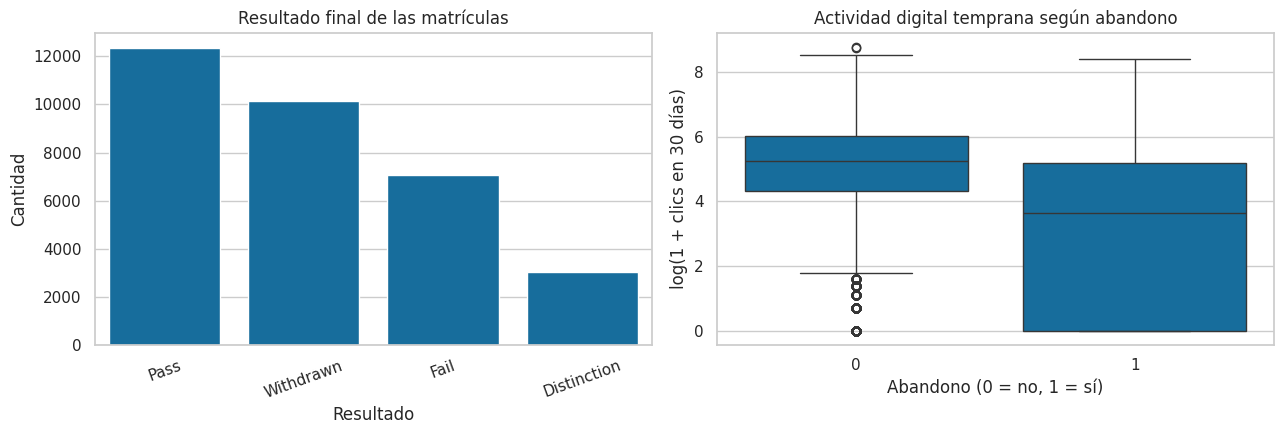

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=base, x='final_result', order=base['final_result'].value_counts().index, ax=axes[0])
axes[0].set(title='Resultado final de las matrículas', xlabel='Resultado', ylabel='Cantidad')
axes[0].tick_params(axis='x', rotation=20)

# El boxplot compara mediana, dispersión y posibles atípicos entre las dos clases.
sns.boxplot(data=base, x='abandono', y='log_clicks_30', ax=axes[1])
axes[1].set(
    title='Actividad digital temprana según abandono',
    xlabel='Abandono (0 = no, 1 = sí)',
    ylabel='log(1 + clics en 30 días)',
)

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '02_resultado_y_actividad.png', dpi=180, bbox_inches='tight')
plt.show()

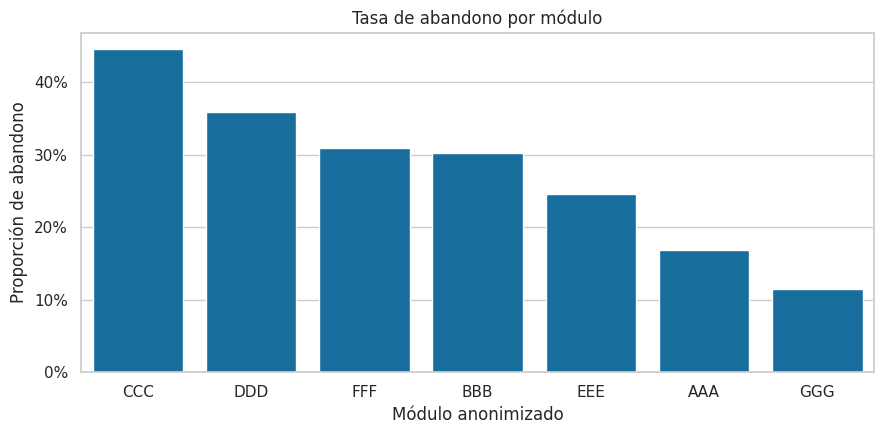

,code_module,matriculas,tasa_abandono
2,CCC,4434,0.445422
3,DDD,6272,0.358737
5,FFF,7762,0.309585
1,BBB,7909,0.301935
4,EEE,2934,0.246080
0,AAA,748,0.168449
6,GGG,2534,0.115233


In [ ]:
# Como abandono es 0/1, su media equivale a la proporción de abandono.
tasa_modulo = (
    base.groupby('code_module', as_index=False)
    .agg(matriculas=('abandono', 'size'), tasa_abandono=('abandono', 'mean'))
    .sort_values('tasa_abandono', ascending=False)
)

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(data=tasa_modulo, x='code_module', y='tasa_abandono')
ax.set(
    title='Tasa de abandono por módulo',
    xlabel='Módulo anonimizado',
    ylabel='Proporción de abandono',
)
ax.yaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '03_tasa_abandono_modulo.png', dpi=180, bbox_inches='tight')
plt.show()

display(tasa_modulo)

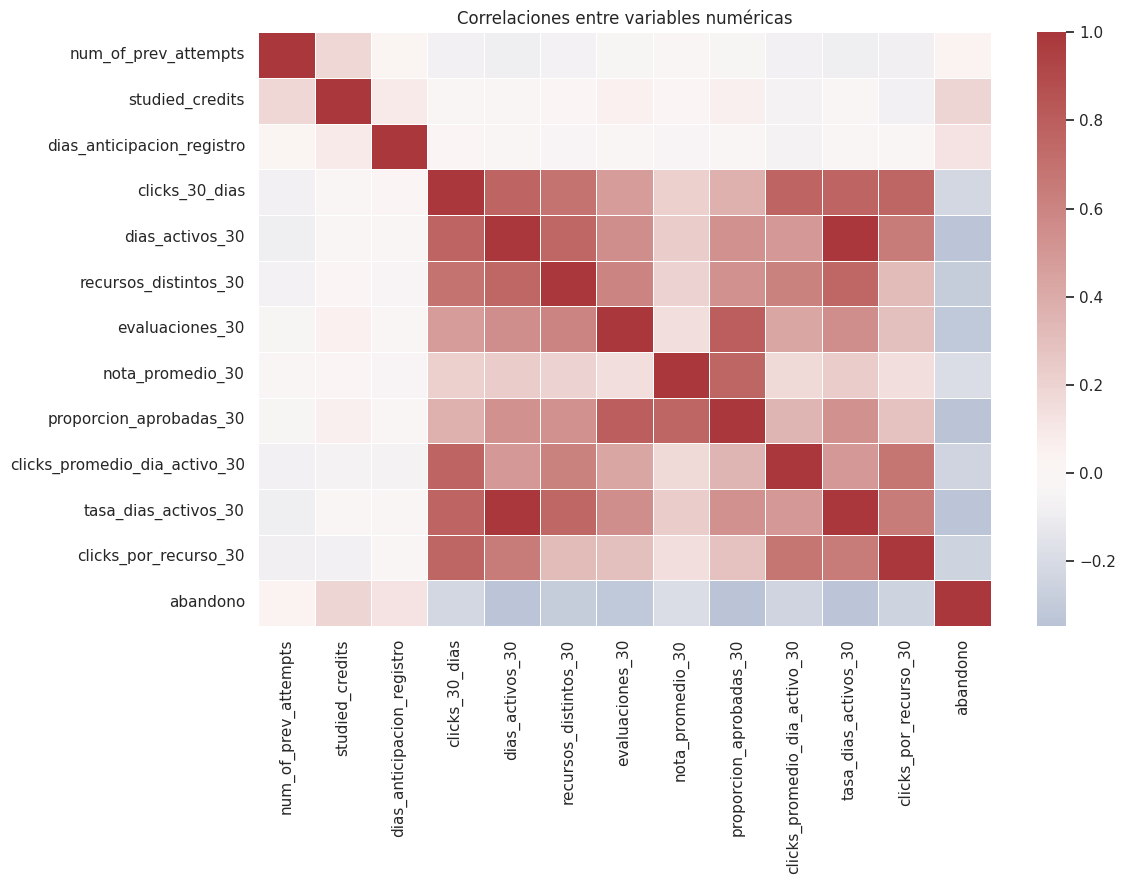

In [ ]:
# Pearson mide relación lineal; una correlación no demuestra causalidad.
correlaciones = base[variables_numericas_eda + ['abandono']].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(correlaciones, cmap='vlag', center=0, linewidths=.4)
plt.title('Correlaciones entre variables numéricas')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '04_correlaciones.png', dpi=180, bbox_inches='tight')
plt.show()

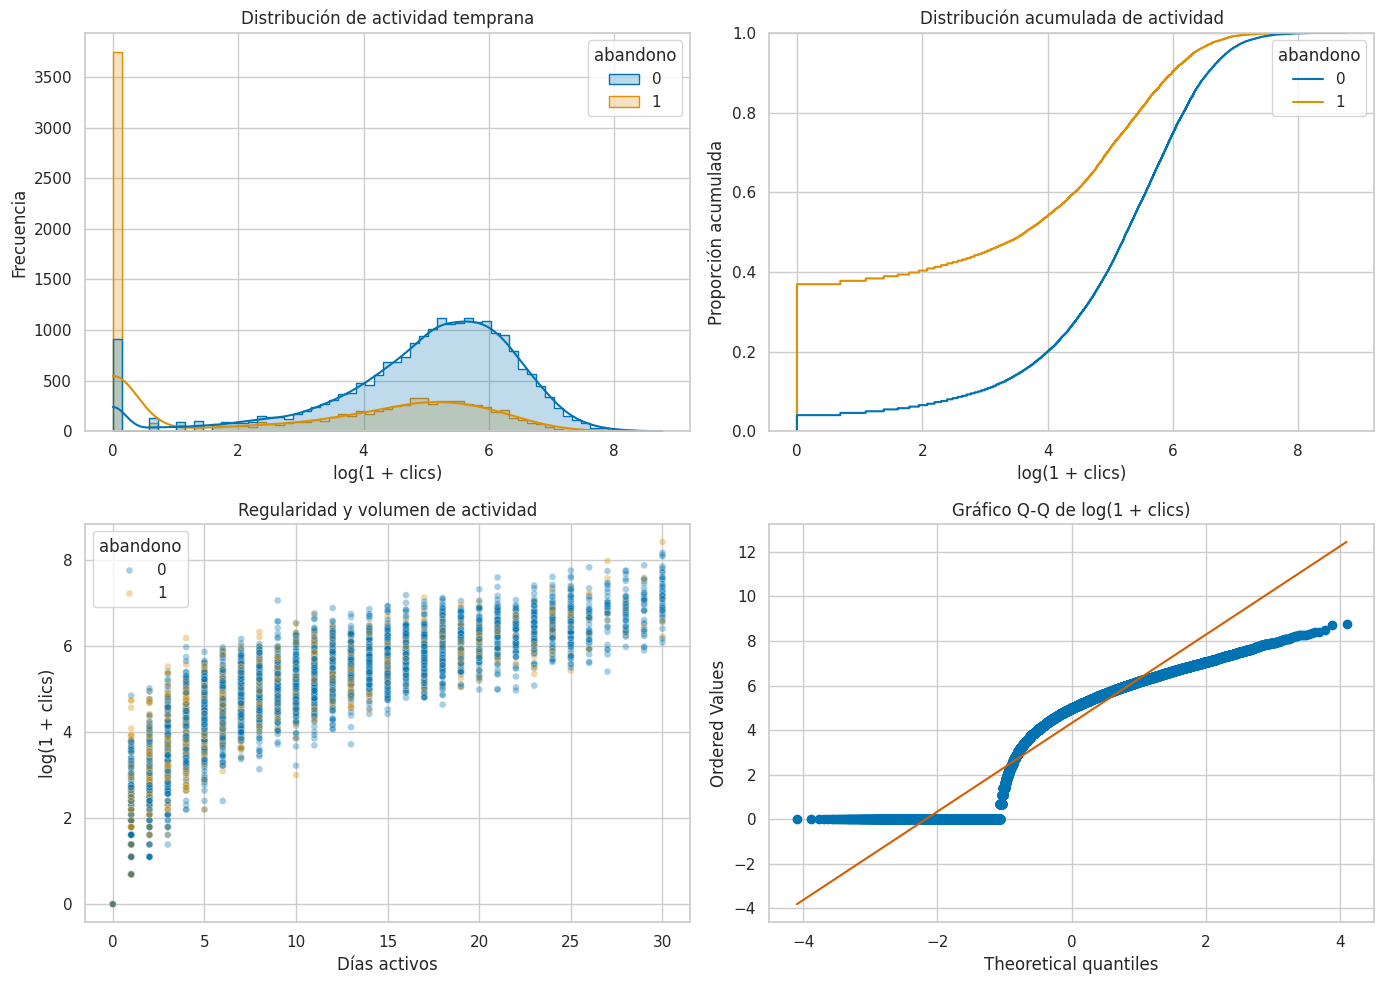

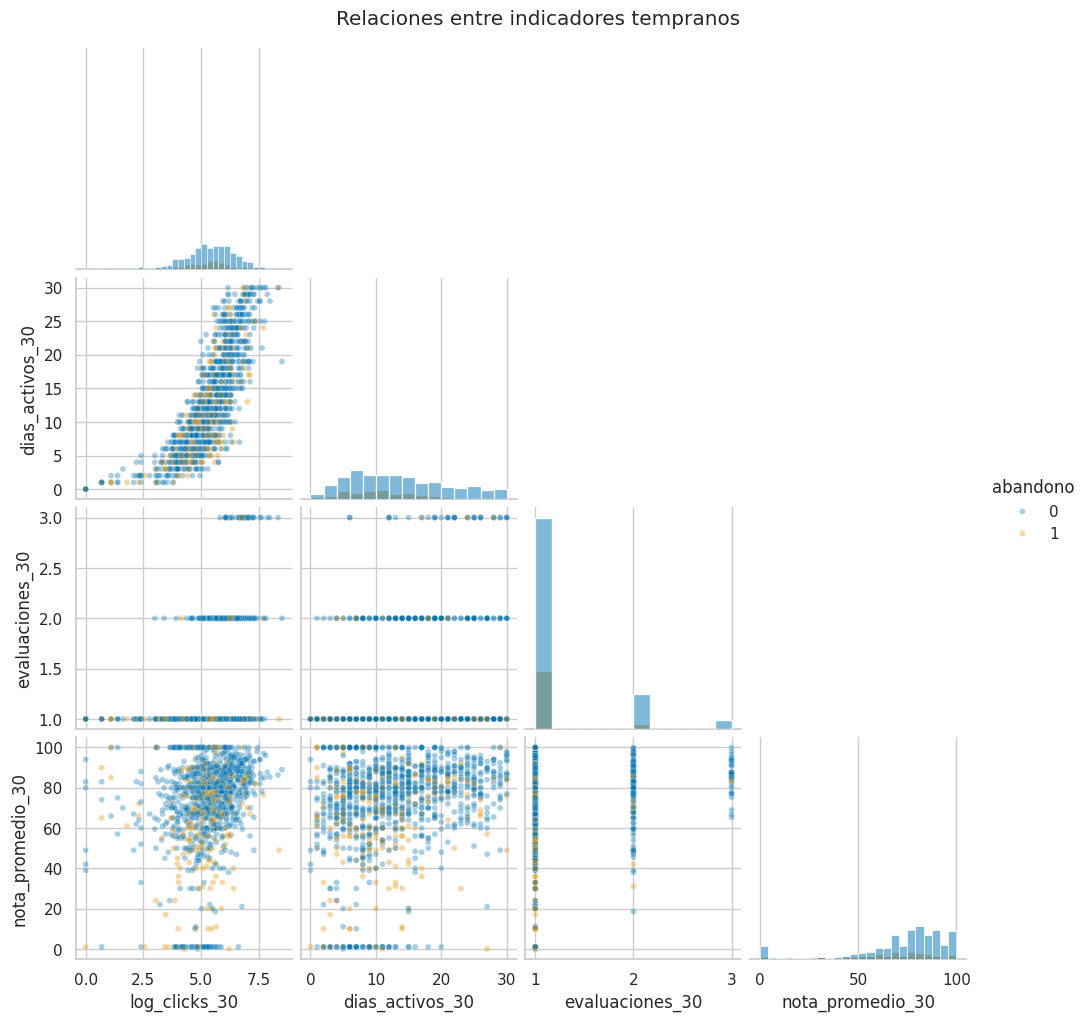

In [ ]:
# Se limita el scatter a 5000 filas para mantener fluida la visualización en Colab.
muestra_grafica = base.sample(n=min(5_000, len(base)), random_state=SEMILLA)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma + KDE: frecuencia observada y forma suavizada de la distribución.
sns.histplot(data=base, x='log_clicks_30', hue='abandono', kde=True, element='step', ax=axes[0, 0])
axes[0, 0].set(title='Distribución de actividad temprana', xlabel='log(1 + clics)', ylabel='Frecuencia')

# ECDF: proporción acumulada de matrículas hasta cada nivel de actividad.
sns.ecdfplot(data=base, x='log_clicks_30', hue='abandono', ax=axes[0, 1])
axes[0, 1].set(title='Distribución acumulada de actividad', xlabel='log(1 + clics)', ylabel='Proporción acumulada')

# La transparencia permite observar zonas densas sin ocultar todos los puntos.
sns.scatterplot(
    data=muestra_grafica,
    x='dias_activos_30',
    y='log_clicks_30',
    hue='abandono',
    alpha=0.35,
    s=24,
    ax=axes[1, 0],
)
axes[1, 0].set(title='Regularidad y volumen de actividad', xlabel='Días activos', ylabel='log(1 + clics)')

# Q-Q compara los cuantiles observados con una distribución normal teórica.
probplot(base['log_clicks_30'].dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Gráfico Q-Q de log(1 + clics)')

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '05_visualizaciones_estadisticas.png', dpi=180, bbox_inches='tight')
plt.show()

# Pairplot sobre una muestra: analiza relaciones múltiples sin sobrecargar memoria.
columnas_pairplot = ['log_clicks_30', 'dias_activos_30', 'evaluaciones_30', 'nota_promedio_30', 'abandono']
muestra_pairplot = base[columnas_pairplot].dropna().sample(
    n=min(1_200, len(base[columnas_pairplot].dropna())),
    random_state=SEMILLA,
)
grafico_pares = sns.pairplot(
    muestra_pairplot,
    vars=columnas_pairplot[:-1],
    hue='abandono',
    corner=True,
    diag_kind='hist',
    plot_kws={'alpha': 0.35, 's': 18},
)
grafico_pares.fig.suptitle('Relaciones entre indicadores tempranos', y=1.02)
grafico_pares.savefig(RUTA_FIGURAS / '06_pairplot_indicadores.png', dpi=160, bbox_inches='tight')
plt.show()

## 11. Valores atípicos

Se utiliza el criterio de rango intercuartílico para documentarlos. No se eliminan automáticamente, porque una actividad muy alta puede corresponder a un estudiante real y no a un error. Para el modelado se emplean transformaciones logarítmicas y escalado robusto.

In [ ]:
filas_outliers = []

for columna in variables_numericas_eda:
    serie = base[columna].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1  # Rango intercuartílico: distancia entre Q1 y Q3.
    # Regla IQR: un valor fuera de estos límites se marca como atípico.
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad = int(((serie < limite_inferior) | (serie > limite_superior)).sum())
    filas_outliers.append({
        'variable': columna,
        'q1': q1,
        'q3': q3,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'cantidad_atipicos': cantidad,
        'porcentaje_atipicos': round(cantidad / len(serie) * 100, 2),
        # Una actividad alta puede ser real; por eso se documenta y no se borra automáticamente.
        'tratamiento': 'Documentar; no eliminar automáticamente',
    })

tabla_outliers = pd.DataFrame(filas_outliers).sort_values(
    'porcentaje_atipicos', ascending=False
)
display(tabla_outliers)

,variable,q1,q3,limite_inferior,limite_superior,cantidad_atipicos,porcentaje_atipicos,tratamiento
0,num_of_prev_attempts,0.000000,0.000000,0.000000,0.000000,4172,12.80,Documentar; no eliminar automáticamente
3,clicks_30_dias,33.000000,342.000000,-430.500000,805.500000,1931,5.92,Documentar; no eliminar automáticamente
7,nota_promedio_30,65.000000,88.000000,30.500000,122.500000,1192,5.84,Documentar; no eliminar automáticamente
11,clicks_por_recurso_30,3.500000,12.714286,-10.321429,26.535714,1462,4.49,Documentar; no eliminar automáticamente
9,clicks_promedio_dia_activo_30,7.923077,26.785714,-20.370879,55.079670,975,2.99,Documentar; no eliminar automáticamente
5,recursos_distintos_30,7.000000,30.000000,-27.500000,64.500000,837,2.57,Documentar; no eliminar automáticamente
6,evaluaciones_30,0.000000,1.000000,-1.500000,2.500000,508,1.56,Documentar; no eliminar automáticamente
1,studied_credits,60.000000,120.000000,-30.000000,210.000000,350,1.07,Documentar; no eliminar automáticamente
2,dias_anticipacion_registro,29.000000,100.000000,-77.500000,206.500000,339,1.04,Documentar; no eliminar automáticamente
4,dias_activos_30,3.000000,15.000000,-15.000000,33.000000,0,0.00,Documentar; no eliminar automáticamente


# Fase 5 — Selección de atributos y reducción dimensional

La selección se documenta antes del modelado:

- información mutua para variables numéricas;
- chi-cuadrado para variables categóricas;
- exclusión metodológica de identificadores y variables con fuga;
- PCA únicamente para visualizar el espacio de participación utilizado por clustering.

,variable,informacion_mutua
3,log_clicks_30,0.100036
10,tasa_dias_activos_30,0.098964
4,dias_activos_30,0.097610
9,clicks_promedio_dia_activo_30,0.097414
5,log_recursos_30,0.095878
11,clicks_por_recurso_30,0.094978
7,nota_promedio_30,0.066061
6,evaluaciones_30,0.065412
8,proporcion_aprobadas_30,0.062997
12,sin_evaluaciones_30,0.056003


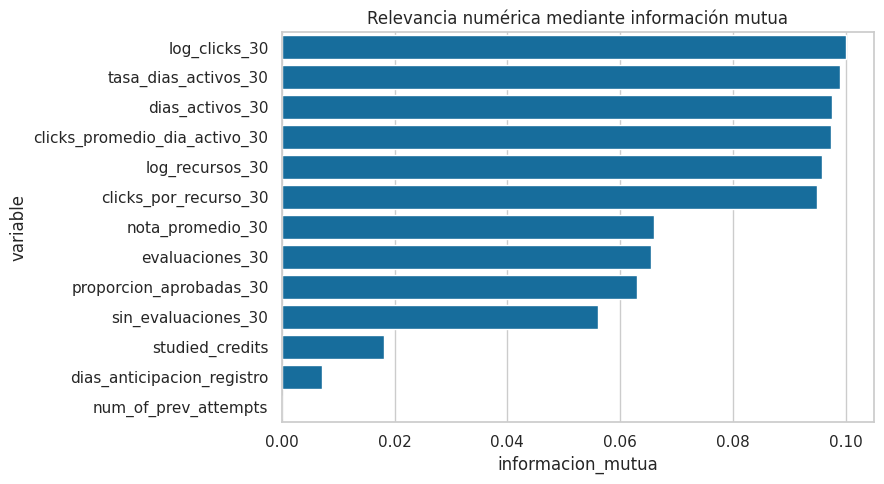

In [ ]:
variables_mi = [
    'num_of_prev_attempts', 'studied_credits', 'dias_anticipacion_registro',
    'log_clicks_30', 'dias_activos_30', 'log_recursos_30',
    'evaluaciones_30', 'nota_promedio_30', 'proporcion_aprobadas_30',
    'clicks_promedio_dia_activo_30', 'tasa_dias_activos_30',
    'clicks_por_recurso_30', 'sin_evaluaciones_30',
]

imputador_mi = SimpleImputer(strategy='median')  # mutual_info_classif no acepta valores nulos.
X_mi = imputador_mi.fit_transform(base[variables_mi])
# La información mutua puede detectar dependencia lineal y no lineal.
mi = mutual_info_classif(X_mi, base['abandono'], random_state=SEMILLA)

relevancia_numerica = pd.DataFrame({
    'variable': variables_mi,
    'informacion_mutua': mi,
}).sort_values('informacion_mutua', ascending=False)

display(relevancia_numerica)

plt.figure(figsize=(9, 5))
sns.barplot(data=relevancia_numerica, y='variable', x='informacion_mutua')
plt.title('Relevancia numérica mediante información mutua')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '05_informacion_mutua.png', dpi=180, bbox_inches='tight')
plt.show()

In [ ]:
variables_categoricas_candidatas = [
    'code_module', 'code_presentation', 'gender', 'region',
    'highest_education', 'imd_band', 'age_band', 'disability',
]

resultados_chi2 = []
for columna in variables_categoricas_candidatas:
    tabla = pd.crosstab(base[columna].fillna('Unknown'), base['abandono'])  # Tabla de frecuencias observadas.
    chi2, p_valor, grados_libertad, _ = chi2_contingency(tabla)  # Contrasta independencia entre variables.
    resultados_chi2.append({
        'variable': columna,
        'chi2': chi2,
        'p_valor': p_valor,
        'grados_libertad': grados_libertad,
        'asociacion_0_05': p_valor < 0.05,  # p < 0,05 indica asociación, no causalidad.
    })

relevancia_categorica = pd.DataFrame(resultados_chi2).sort_values('p_valor')
display(relevancia_categorica)

,variable,chi2,p_valor,grados_libertad,asociacion_0_05
0,code_module,1024.429393,4.651078e-218,6,True
5,imd_band,254.178619,7.174884e-49,10,True
4,highest_education,202.223384,1.249757e-42,4,True
3,region,194.450324,4.550304e-35,12,True
1,code_presentation,152.695770,6.905659e-33,3,True
7,disability,109.122829,1.525346e-25,1,True
6,age_band,38.280658,4.869236e-09,2,True
2,gender,5.733818,1.664126e-02,1,True


## 12. PCA y clustering K-Means

El objetivo del clustering es describir perfiles de participación, no predecir el abandono. Por ello, `abandono`, `final_result`, identificadores y variables sensibles no participan en la formación de grupos.

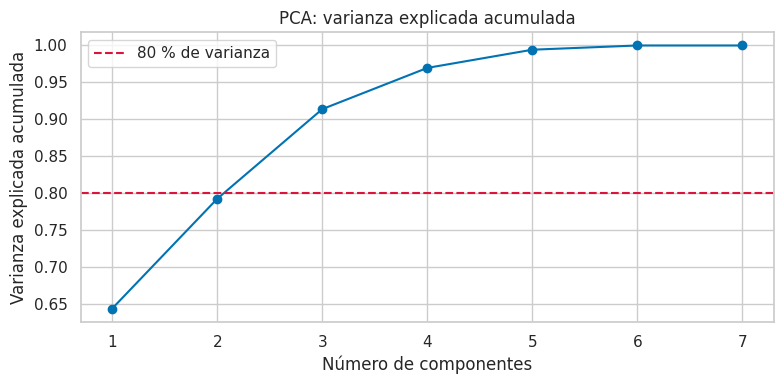

In [ ]:
# Solo incluye participación y desempeño temprano; no incluye abandono ni datos sensibles.
VARIABLES_CLUSTER = [
    'log_clicks_30',
    'dias_activos_30',
    'log_recursos_30',
    'evaluaciones_30',
    'nota_promedio_30',
    'proporcion_aprobadas_30',
    'tasa_dias_activos_30',
]

imputador_cluster = SimpleImputer(strategy='median')  # Completa nulos sin usar el objetivo.
escalador_cluster = StandardScaler()  # K-Means usa distancias y requiere escalas comparables.

X_cluster_imputado = imputador_cluster.fit_transform(base[VARIABLES_CLUSTER])
X_cluster = escalador_cluster.fit_transform(X_cluster_imputado)

pca_total = PCA().fit(X_cluster)
varianza_acumulada = np.cumsum(pca_total.explained_variance_ratio_)  # Suma la varianza explicada componente a componente.

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(0.80, color='crimson', linestyle='--', label='80 % de varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA: varianza explicada acumulada')
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '06_pca_varianza.png', dpi=180, bbox_inches='tight')
plt.show()

,k,inercia,silhouette
0,2,123577.632952,0.435403
1,3,93661.999660,0.341421
2,4,69944.883052,0.403359
3,5,51251.459263,0.449742
4,6,44802.667395,0.398232
5,7,38910.684015,0.408408
6,8,33791.820634,0.424025


K seleccionado por mayor silhouette: 5


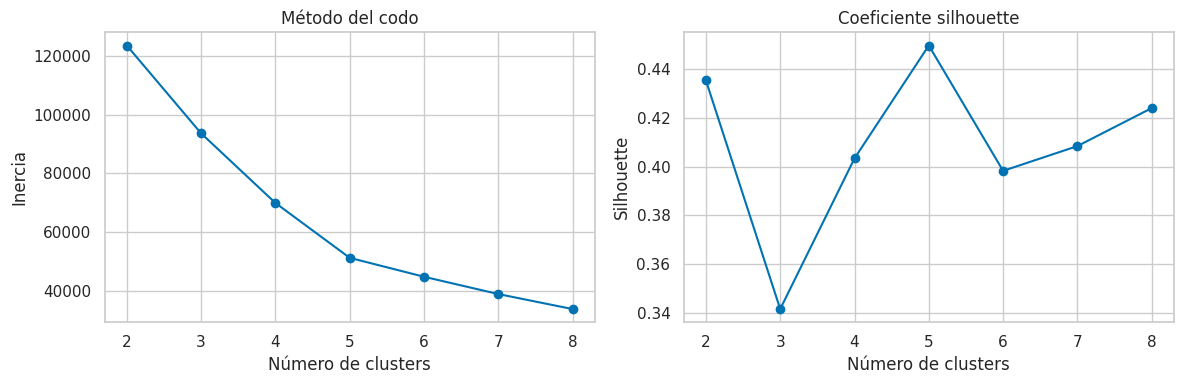

In [ ]:
resultados_k = []

# Se prueban de 2 a 8 grupos; range no incluye el límite superior 9.
for k in range(2, 9):
    candidato = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,  # Ejecuta 20 inicializaciones y conserva la de menor inercia.
        max_iter=300,
        random_state=SEMILLA,
    )
    etiquetas = candidato.fit_predict(X_cluster)
    silueta = silhouette_score(
        X_cluster,
        etiquetas,
        sample_size=min(10_000, len(X_cluster)),  # Limita el costo del cálculo de silhouette.
        random_state=SEMILLA,
    )
    resultados_k.append({
        'k': k,
        'inercia': candidato.inertia_,
        'silhouette': silueta,
    })

evaluacion_k = pd.DataFrame(resultados_k)
MEJOR_K = int(evaluacion_k.loc[evaluacion_k['silhouette'].idxmax(), 'k'])  # Mayor valor = grupos más separados.
display(evaluacion_k)
print('K seleccionado por mayor silhouette:', MEJOR_K)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(evaluacion_k['k'], evaluacion_k['inercia'], marker='o')
axes[0].set(title='Método del codo', xlabel='Número de clusters', ylabel='Inercia')
axes[1].plot(evaluacion_k['k'], evaluacion_k['silhouette'], marker='o')
axes[1].set(title='Coeficiente silhouette', xlabel='Número de clusters', ylabel='Silhouette')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '07_seleccion_k.png', dpi=180, bbox_inches='tight')
plt.show()

,k,silhouette,davies_bouldin,calinski_harabasz,dunn_aproximado,inercia
0,5,0.4497,0.8225,28120.2022,0.0122,51251.4593


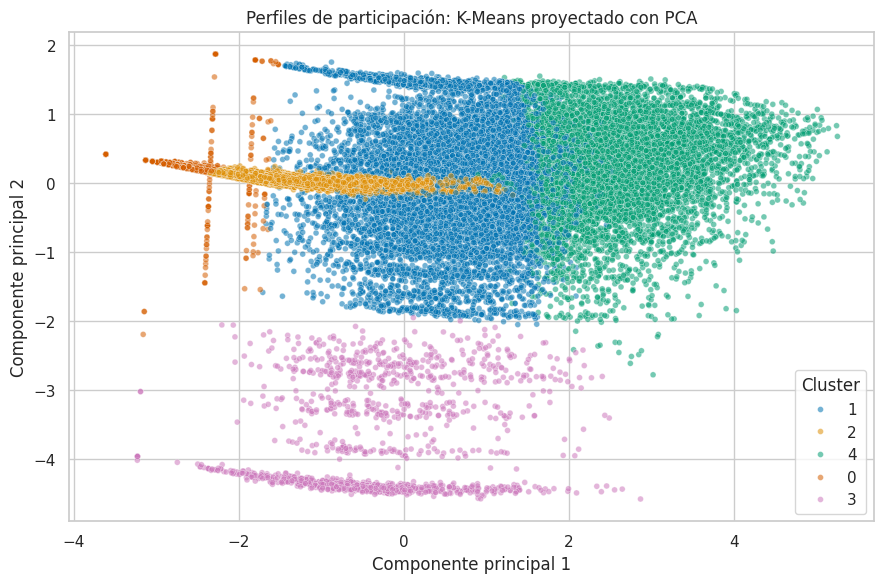

In [ ]:
def indice_dunn_aproximado(datos, etiquetas, max_muestra=2_000, semilla=42):
    # Calcula Dunn sobre una muestra para evitar una matriz de distancias de 32 mil filas.
    generador = np.random.default_rng(semilla)
    indices = np.arange(len(datos))

    # Dunn requiere distancias entre pares; limitar la muestra evita agotar la RAM de Colab.
    if len(indices) > max_muestra:
        indices = generador.choice(indices, size=max_muestra, replace=False)

    datos_muestra = datos[indices]
    etiquetas_muestra = np.asarray(etiquetas)[indices]
    distancias = pairwise_distances(datos_muestra)  # Matriz cuadrada solo de la muestra.
    grupos = np.unique(etiquetas_muestra)

    diametros = []
    separaciones = []

    for grupo in grupos:
        posiciones = np.where(etiquetas_muestra == grupo)[0]
        if len(posiciones) > 1:
            diametros.append(distancias[np.ix_(posiciones, posiciones)].max())

    for posicion, grupo_a in enumerate(grupos[:-1]):
        indices_a = np.where(etiquetas_muestra == grupo_a)[0]
        for grupo_b in grupos[posicion + 1:]:
            indices_b = np.where(etiquetas_muestra == grupo_b)[0]
            separaciones.append(distancias[np.ix_(indices_a, indices_b)].min())

    # Dunn = mínima separación entre grupos / máximo diámetro dentro de un grupo.
    if not diametros or not separaciones or max(diametros) == 0:
        return np.nan
    return min(separaciones) / max(diametros)


kmeans_final = KMeans(
    n_clusters=MEJOR_K,
    init='k-means++',
    n_init=30,  # Reduce el riesgo de seleccionar centroides iniciales desfavorables.
    max_iter=300,
    random_state=SEMILLA,
)
base['cluster'] = kmeans_final.fit_predict(X_cluster)

metricas_cluster = pd.DataFrame([{
    'k': MEJOR_K,
    'silhouette': silhouette_score(
        X_cluster,
        base['cluster'],
        sample_size=min(10_000, len(X_cluster)),
        random_state=SEMILLA,
    ),
    'davies_bouldin': davies_bouldin_score(X_cluster, base['cluster']),  # Menor es mejor.
    'calinski_harabasz': calinski_harabasz_score(X_cluster, base['cluster']),  # Mayor es mejor.
    'dunn_aproximado': indice_dunn_aproximado(X_cluster, base['cluster'], semilla=SEMILLA),  # Mayor es mejor.
    'inercia': kmeans_final.inertia_,
}])
display(metricas_cluster.round(4))

pca_2d = PCA(n_components=2, random_state=SEMILLA)  # Solo proyecta los grupos para graficarlos.
coordenadas = pca_2d.fit_transform(X_cluster)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=coordenadas[:, 0],
    y=coordenadas[:, 1],
    hue=base['cluster'].astype(str),
    s=18,
    alpha=.55,
)
plt.title('Perfiles de participación: K-Means proyectado con PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '08_clusters_pca.png', dpi=180, bbox_inches='tight')
plt.show()

,cluster,matriculas,clicks_promedio,dias_activos_promedio,recursos_promedio,evaluaciones_promedio,nota_promedio,tasa_abandono
0,0,5884,1.165,0.298,0.502,0.028,71.134,0.724
1,1,11046,169.895,8.419,20.830,1.081,75.119,0.201
2,2,6249,158.632,7.358,14.477,0.001,NaN,0.322
3,3,1417,173.810,8.715,20.747,1.035,12.368,0.387
4,4,7997,630.668,20.815,41.199,1.287,80.836,0.139


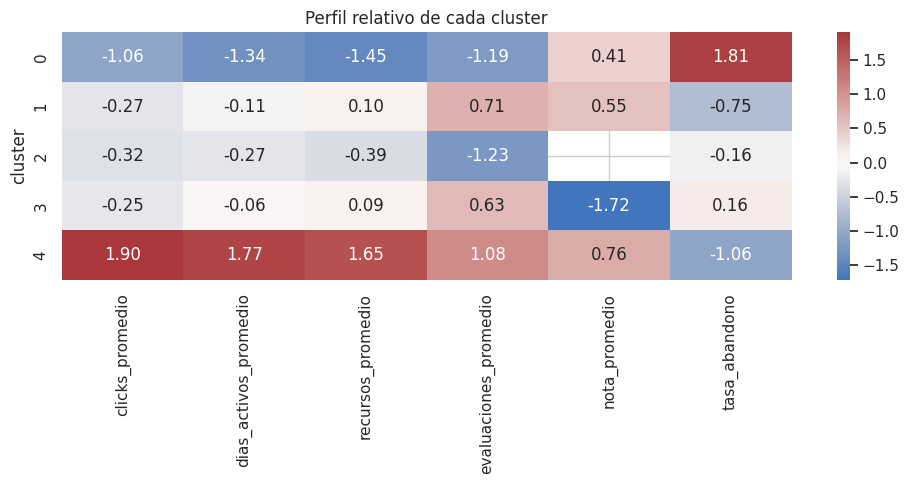


INTERPRETACIÓN AUTOMÁTICA DE LOS PERFILES
- Cluster 0: destaca por nota_promedio, clicks_promedio; sus valores relativos más bajos están en recursos_promedio, dias_activos_promedio; tasa observada de abandono = 72.42%.
- Cluster 1: destaca por evaluaciones_promedio, nota_promedio; sus valores relativos más bajos están en clicks_promedio, dias_activos_promedio; tasa observada de abandono = 20.14%.
- Cluster 2: destaca por dias_activos_promedio, clicks_promedio; sus valores relativos más bajos están en evaluaciones_promedio, recursos_promedio; tasa observada de abandono = 32.18%.
- Cluster 3: destaca por evaluaciones_promedio, recursos_promedio; sus valores relativos más bajos están en nota_promedio, clicks_promedio; tasa observada de abandono = 38.67%.
- Cluster 4: destaca por clicks_promedio, dias_activos_promedio; sus valores relativos más bajos están en nota_promedio, evaluaciones_promedio; tasa observada de abandono = 13.89%.


In [ ]:
# abandono no formó los clusters; se consulta después únicamente para interpretarlos.
perfil_cluster = (
    base.groupby('cluster', as_index=False)
    .agg(
        matriculas=('id_student', 'size'),
        clicks_promedio=('clicks_30_dias', 'mean'),
        dias_activos_promedio=('dias_activos_30', 'mean'),
        recursos_promedio=('recursos_distintos_30', 'mean'),
        evaluaciones_promedio=('evaluaciones_30', 'mean'),
        nota_promedio=('nota_promedio_30', 'mean'),
        tasa_abandono=('abandono', 'mean'),
    )
)

display(perfil_cluster.round(3))
perfil_cluster.to_csv(RUTA_SALIDAS / 'perfiles_cluster.csv', index=False)

perfil_heatmap = perfil_cluster.set_index('cluster').drop(columns=['matriculas'])
perfil_estandarizado = (
    perfil_heatmap - perfil_heatmap.mean()
) / perfil_heatmap.std(ddof=0)  # z > 0 significa valor superior al promedio general.

plt.figure(figsize=(10, 5))
sns.heatmap(perfil_estandarizado, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Perfil relativo de cada cluster')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '09_perfiles_cluster.png', dpi=180, bbox_inches='tight')
plt.show()

print('\nINTERPRETACIÓN AUTOMÁTICA DE LOS PERFILES')
variables_perfil = perfil_estandarizado.drop(columns=['tasa_abandono'], errors='ignore')
for cluster_id, fila in variables_perfil.iterrows():
    indicadores_altos = ', '.join(fila.nlargest(2).index)
    indicadores_bajos = ', '.join(fila.nsmallest(2).index)
    tasa = perfil_cluster.loc[perfil_cluster['cluster'].eq(cluster_id), 'tasa_abandono'].iloc[0]
    print(
        f'- Cluster {cluster_id}: destaca por {indicadores_altos}; '
        f'sus valores relativos más bajos están en {indicadores_bajos}; '
        f'tasa observada de abandono = {tasa:.2%}.'
    )

# Fase 6 — Modelado predictivo

## 13. Variables de entrada

Se excluyen explícitamente:

- `id_student`: identificador sin significado predictivo generalizable;
- `final_result`: contiene la respuesta;
- `date_unregistration`: contiene la fecha del abandono;
- `cluster`: se mantiene como resultado descriptivo y no se usa para favorecer artificialmente la predicción.

La selección del mejor clasificador se realizará con el F1 promedio de validación cruzada, no con el conjunto de prueba.

In [ ]:
# Estas variables se conservan únicamente para auditoría; no intervienen en el entrenamiento.
VARIABLES_SENSIBLES_AUDITORIA = ['gender', 'disability', 'imd_band']

# La futura API enviará exactamente estas variables categóricas, sin cálculos externos ocultos.
VARIABLES_CATEGORICAS = [
    'code_module',
    'code_presentation',
    'highest_education',
    'age_band',
]

# Se usan indicadores comprensibles que una institución podría conocer al finalizar el día 30.
VARIABLES_NUMERICAS_MODELO = [
    'num_of_prev_attempts',
    'studied_credits',
    'dias_anticipacion_registro',
    'clicks_30_dias',
    'dias_activos_30',
    'recursos_distintos_30',
    'evaluaciones_30',
    'nota_promedio_30',
    'proporcion_aprobadas_30',
    'entregas_tardias_30',
]

for columna in VARIABLES_CATEGORICAS:
    # Unknown conserva el faltante como categoría explícita y evita eliminar matrículas.
    base[columna] = base[columna].astype('string').fillna('Unknown').astype(str)

VARIABLES_MODELO = VARIABLES_CATEGORICAS + VARIABLES_NUMERICAS_MODELO
X = base[VARIABLES_MODELO].copy()  # Matriz de variables predictoras.
y = base['abandono'].copy()        # Etiqueta binaria que el modelo debe aprender.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,  # Mantiene una proporción similar de abandono en ambos conjuntos.
    random_state=SEMILLA,
)

resumen_particion = pd.DataFrame([
    ['Entrenamiento', len(X_train), y_train.mean()],
    ['Prueba', len(X_test), y_test.mean()],
], columns=['conjunto', 'registros', 'proporcion_abandono'])

display(resumen_particion)
print('Variables utilizadas por el modelo:', len(VARIABLES_MODELO))
print('Variables sensibles excluidas:', VARIABLES_SENSIBLES_AUDITORIA)

,conjunto,registros,proporcion_abandono
0,Entrenamiento,26074,0.311613
1,Prueba,6519,0.311551


Variables utilizadas por el modelo: 14
Variables sensibles excluidas: ['gender', 'disability', 'imd_band']


In [ ]:
def crear_preprocesador():
    numerico = Pipeline(steps=[
        ('imputacion', SimpleImputer(strategy='median', add_indicator=True)),  # Añade una marca cuando faltaba el dato.
        ('escalado', RobustScaler()),  # Usa mediana e IQR; es menos sensible a atípicos.
    ])

    categorico = Pipeline(steps=[
        ('imputacion', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore', min_frequency=10)),  # Evita error con categorías nuevas y agrupa las muy raras.
    ])

    return ColumnTransformer(
        transformers=[
            ('numericas', numerico, VARIABLES_NUMERICAS_MODELO),
            ('categoricas', categorico, VARIABLES_CATEGORICAS),
        ],
        remainder='drop',
    )


# El pipeline aplica el preprocesamiento dentro de cada entrenamiento y evita fuga de datos.
def crear_pipeline(modelo):
    return Pipeline(steps=[
        ('preprocesamiento', crear_preprocesador()),
        ('modelo', modelo),
    ])


MODELOS = {
    'Regresión logística': crear_pipeline(
        LogisticRegression(
            C=1.0,
            class_weight='balanced',  # Da más peso a la clase menos frecuente.
            solver='liblinear',
            max_iter=2000,
            random_state=SEMILLA,
        )
    ),
    'Árbol de decisión': crear_pipeline(
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_split=40,
            min_samples_leaf=20,
            class_weight='balanced',
            random_state=SEMILLA,
        )
    ),
    'Bosque aleatorio': crear_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            max_depth=18,
            min_samples_leaf=5,
            max_features='sqrt',
            class_weight='balanced_subsample',  # Recalcula los pesos en cada muestra del bosque.
            n_jobs=-1,
            random_state=SEMILLA,
        )
    ),
}

tabla_parametros = pd.DataFrame([
    {
        'modelo': 'Regresión logística',
        'parámetros principales': 'C=1.0; class_weight=balanced; solver=liblinear; max_iter=2000',
    },
    {
        'modelo': 'Árbol de decisión',
        'parámetros principales': 'max_depth=8; min_samples_split=40; min_samples_leaf=20; class_weight=balanced',
    },
    {
        'modelo': 'Bosque aleatorio',
        'parámetros principales': 'n_estimators=200; max_depth=18; min_samples_leaf=5; max_features=sqrt; class_weight=balanced_subsample',
    },
])

display(tabla_parametros)

,modelo,parámetros principales
0,Regresión logística,C=1.0; class_weight=balanced; solver=liblinear...
1,Árbol de decisión,max_depth=8; min_samples_split=40; min_samples...
2,Bosque aleatorio,n_estimators=200; max_depth=18; min_samples_le...


## 14. Validación cruzada y comparación

- División externa: 80 % entrenamiento y 20 % prueba, estratificada.
- Comparación de algoritmos: `StratifiedKFold` con 5 particiones aplicadas únicamente al entrenamiento.
- Desbalance: pesos de clase configurados dentro de cada algoritmo.
- Métrica principal de selección: F1 promedio de validación cruzada.
- Métricas comparadas: accuracy, precision, recall, F1 y ROC-AUC.
- El conjunto de prueba no participa en la selección del algoritmo y se utiliza una sola vez para evaluar el modelo ganador.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEMILLA,
)  # Cinco particiones con una proporción de clases estable.

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

filas_resultados = []
filas_por_fold = []

for nombre, pipeline in MODELOS.items():
    print(f'Procesando validación cruzada: {nombre}')

    # El pipeline completo se ajusta de nuevo en cada fold para impedir fuga de preprocesamiento.
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,  # Evita que varios modelos grandes compitan por toda la RAM de Colab.
        return_train_score=False,
    )

    fila = {'modelo': nombre}
    for metrica in scoring:
        valores = cv_scores[f'test_{metrica}']
        fila[f'cv_{metrica}_media'] = valores.mean()
        fila[f'cv_{metrica}_std'] = valores.std(ddof=1)

        # Conserva cada fold para visualizar estabilidad, no solo el promedio.
        for numero_fold, valor in enumerate(valores, start=1):
            filas_por_fold.append({
                'modelo': nombre,
                'fold': numero_fold,
                'metrica': metrica,
                'valor': valor,
            })

    filas_resultados.append(fila)

# El ganador se decide por F1 y, en caso de empate, por ROC-AUC; nunca por el test.
resultados_modelos = pd.DataFrame(filas_resultados).sort_values(
    ['cv_f1_media', 'cv_roc_auc_media'],
    ascending=False,
).reset_index(drop=True)
resultados_folds = pd.DataFrame(filas_por_fold)

display(resultados_modelos.round(4))
resultados_modelos.to_csv(RUTA_SALIDAS / 'comparacion_modelos_cv.csv', index=False)
resultados_folds.to_csv(RUTA_SALIDAS / 'resultados_por_fold.csv', index=False)

ganador_cv = resultados_modelos.iloc[0]
print(
    f"Mejor algoritmo por validación: {ganador_cv['modelo']} | "
    f"F1={ganador_cv['cv_f1_media']:.4f} ± {ganador_cv['cv_f1_std']:.4f} | "
    f"ROC-AUC={ganador_cv['cv_roc_auc_media']:.4f}."
)

Procesando validación cruzada: Regresión logística
Procesando validación cruzada: Árbol de decisión
Procesando validación cruzada: Bosque aleatorio


,modelo,cv_accuracy_media,cv_accuracy_std,cv_precision_media,cv_precision_std,cv_recall_media,cv_recall_std,cv_f1_media,cv_f1_std,cv_roc_auc_media,cv_roc_auc_std
0,Bosque aleatorio,0.8026,0.0070,0.6972,0.0138,0.6479,0.0118,0.6716,0.0112,0.8300,0.0091
1,Regresión logística,0.7766,0.0065,0.6304,0.0094,0.6841,0.0133,0.6561,0.0107,0.8140,0.0084
2,Árbol de decisión,0.7774,0.0076,0.6341,0.0123,0.6759,0.0142,0.6543,0.0117,0.8152,0.0093


Mejor algoritmo por validación: Bosque aleatorio | F1=0.6716 ± 0.0112 | ROC-AUC=0.8300.


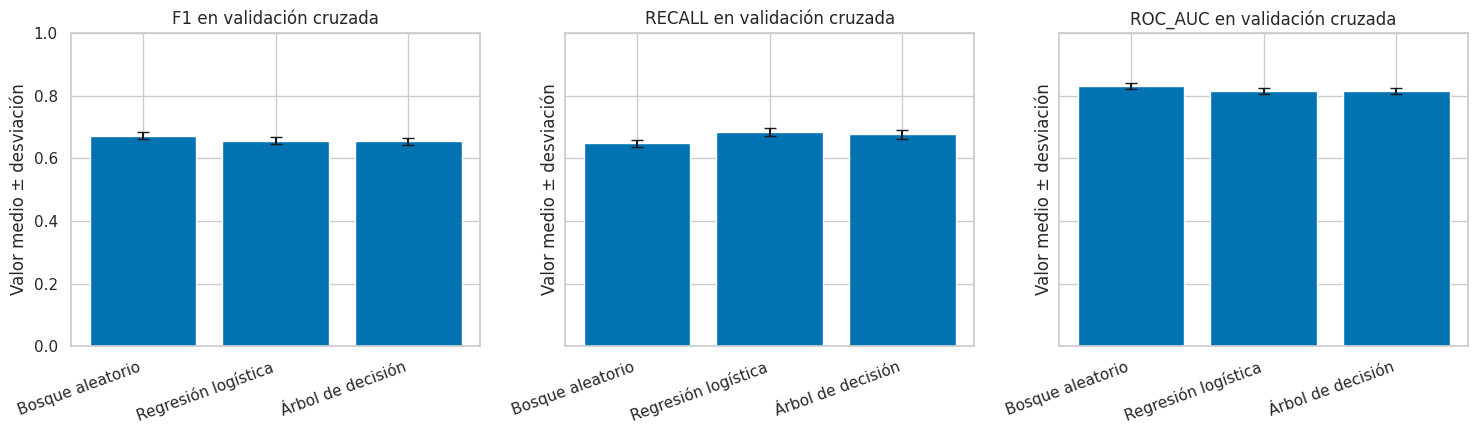

In [ ]:
metricas_comparables = ['f1', 'recall', 'roc_auc']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, metrica in zip(axes, metricas_comparables):
    medias = resultados_modelos[f'cv_{metrica}_media']
    desviaciones = resultados_modelos[f'cv_{metrica}_std']
    posiciones = np.arange(len(resultados_modelos))

    ax.bar(posiciones, medias, yerr=desviaciones, capsize=4)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(resultados_modelos['modelo'], rotation=20, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title(f'{metrica.upper()} en validación cruzada')
    ax.set_ylabel('Valor medio ± desviación')

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '10_comparacion_modelos_cv.png', dpi=180, bbox_inches='tight')
plt.show()

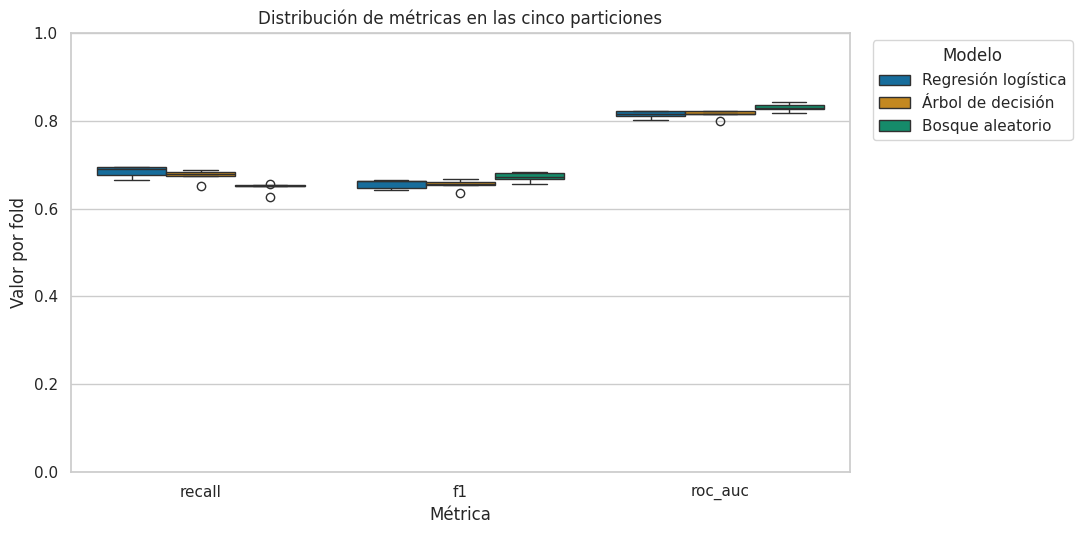

In [ ]:
# El boxplot muestra estabilidad: una caja estrecha representa menor variación entre folds.
plt.figure(figsize=(11, 5.5))
sns.boxplot(
    data=resultados_folds[resultados_folds['metrica'].isin(['f1', 'recall', 'roc_auc'])],
    x='metrica',
    y='valor',
    hue='modelo',
)
plt.ylim(0, 1)
plt.title('Distribución de métricas en las cinco particiones')
plt.xlabel('Métrica')
plt.ylabel('Valor por fold')
plt.legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '11_estabilidad_modelos_cv.png', dpi=180, bbox_inches='tight')
plt.show()

## 15. Selección, calibración y prueba final

El algoritmo se selecciona por el mayor F1 medio de validación cruzada. Después se calibra con método sigmoide utilizando únicamente el conjunto de entrenamiento. Solo entonces se consulta una vez el conjunto de prueba para producir las métricas, la matriz de confusión y la curva ROC finales.

Modelo seleccionado por CV F1: Bosque aleatorio


,modelo,accuracy,precision,recall,f1,roc_auc,brier_score
0,Bosque aleatorio calibrado,0.8096,0.7513,0.5815,0.6556,0.8358,0.1398


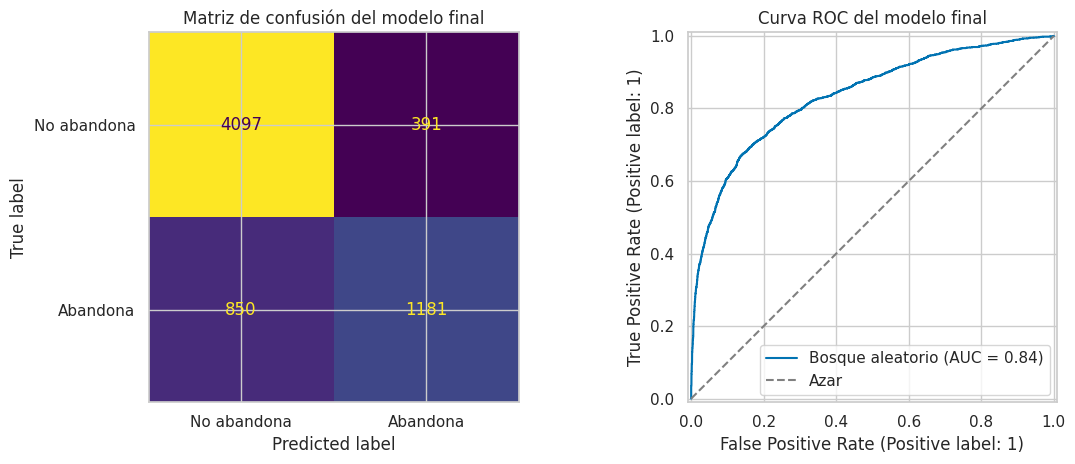


INTERPRETACIÓN AUTOMÁTICA DEL MODELO FINAL
- Recall = 58.15%: proporción de abandonos reales detectados.
- Precision = 75.13%: proporción de alertas que correspondieron a abandonos.
- F1 = 0.6556: equilibrio entre precision y recall.
- ROC-AUC = 0.8358: capacidad de separar ambas clases.
- Falsos negativos = 850: abandonos que el sistema no alertó.
- Falsos positivos = 391: alertas preventivas en estudiantes que no abandonaron.


In [ ]:
MEJOR_MODELO_NOMBRE = resultados_modelos.iloc[0]['modelo']  # Primera fila: mayor F1 medio de CV.
print('Modelo seleccionado por CV F1:', MEJOR_MODELO_NOMBRE)

modelo_final_evaluacion = CalibratedClassifierCV(
    estimator=clone(MODELOS[MEJOR_MODELO_NOMBRE]),
    method='sigmoid',  # Ajusta predict_proba para representar mejor el nivel de riesgo.
    cv=cv,
    n_jobs=1,          # Evita paralelismo anidado si el ganador es bosque aleatorio.
    ensemble=False,    # Conserva un modelo base final y reduce considerablemente el archivo.
)
modelo_final_evaluacion.fit(X_train, y_train)

y_pred_final = modelo_final_evaluacion.predict(X_test)
y_prob_final = modelo_final_evaluacion.predict_proba(X_test)[:, 1]  # Probabilidad de abandono=1.
matriz_final = confusion_matrix(y_test, y_pred_final)

metricas_finales = pd.DataFrame([{
    'modelo': f'{MEJOR_MODELO_NOMBRE} calibrado',
    'accuracy': accuracy_score(y_test, y_pred_final),
    'precision': precision_score(y_test, y_pred_final, zero_division=0),
    'recall': recall_score(y_test, y_pred_final, zero_division=0),
    'f1': f1_score(y_test, y_pred_final, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob_final),
    'brier_score': brier_score_loss(y_test, y_prob_final),  # Menor es mejor para probabilidades.
}])

display(metricas_finales.round(4))
metricas_finales.to_csv(RUTA_SALIDAS / 'metricas_modelo_final.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ConfusionMatrixDisplay(
    confusion_matrix=matriz_final,
    display_labels=['No abandona', 'Abandona'],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión del modelo final')

RocCurveDisplay.from_predictions(y_test, y_prob_final, name=MEJOR_MODELO_NOMBRE, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
axes[1].set_title('Curva ROC del modelo final')
axes[1].legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '12_evaluacion_modelo_final.png', dpi=180, bbox_inches='tight')
plt.show()

resultado = metricas_finales.iloc[0]
verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos = matriz_final.ravel()
print('\nINTERPRETACIÓN AUTOMÁTICA DEL MODELO FINAL')
print(f"- Recall = {resultado['recall']:.2%}: proporción de abandonos reales detectados.")
print(f"- Precision = {resultado['precision']:.2%}: proporción de alertas que correspondieron a abandonos.")
print(f"- F1 = {resultado['f1']:.4f}: equilibrio entre precision y recall.")
print(f"- ROC-AUC = {resultado['roc_auc']:.4f}: capacidad de separar ambas clases.")
print(f'- Falsos negativos = {falsos_negativos}: abandonos que el sistema no alertó.')
print(f'- Falsos positivos = {falsos_positivos}: alertas preventivas en estudiantes que no abandonaron.')

,variable,importancia_media_roc_auc,desviacion
0,code_module,0.0539,0.0028
11,nota_promedio_30,0.0298,0.0023
12,proporcion_aprobadas_30,0.0194,0.0025
5,studied_credits,0.0130,0.0015
10,evaluaciones_30,0.0100,0.0022
8,dias_activos_30,0.0090,0.0011
7,clicks_30_dias,0.0061,0.0007
1,code_presentation,0.0055,0.0009
9,recursos_distintos_30,0.0048,0.0004
2,highest_education,0.0036,0.0015


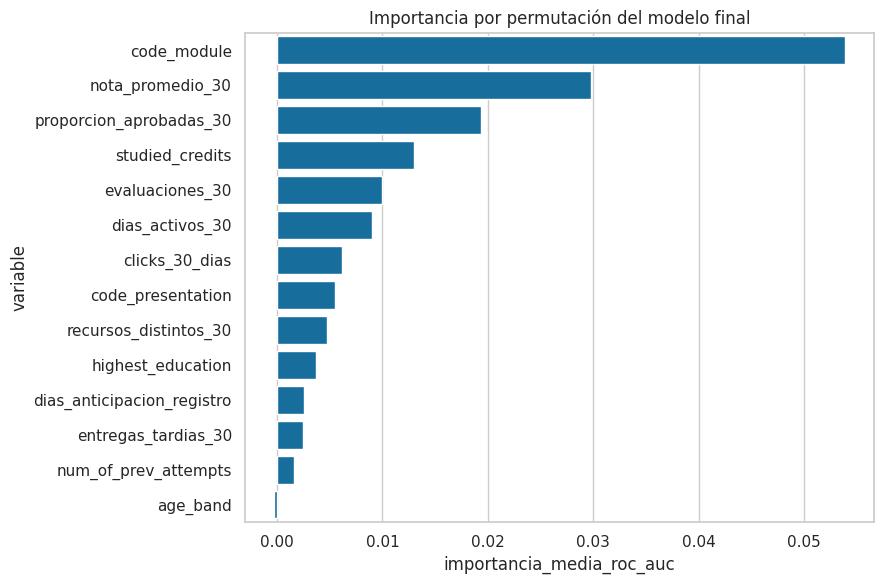

Variables con mayor aporte predictivo observado: code_module, nota_promedio_30, proporcion_aprobadas_30, studied_credits, evaluaciones_30
La importancia indica asociación útil para predecir; no demuestra causalidad.


In [ ]:
# Desordena una variable por vez y mide cuánto disminuye el ROC-AUC del modelo ya evaluado.
importancia = permutation_importance(
    modelo_final_evaluacion,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=5,  # Repite la permutación para reducir el efecto de una sola alteración aleatoria.
    random_state=SEMILLA,
    n_jobs=-1,
)

importancia_variables = pd.DataFrame({
    'variable': VARIABLES_MODELO,
    'importancia_media_roc_auc': importancia.importances_mean,
    'desviacion': importancia.importances_std,
}).sort_values('importancia_media_roc_auc', ascending=False)

display(importancia_variables.head(15).round(4))
importancia_variables.to_csv(RUTA_SALIDAS / 'importancia_variables.csv', index=False)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=importancia_variables.head(15),
    y='variable',
    x='importancia_media_roc_auc',
)
plt.title('Importancia por permutación del modelo final')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / '13_importancia_variables.png', dpi=180, bbox_inches='tight')
plt.show()

principales = ', '.join(importancia_variables.head(5)['variable'].tolist())
print('Variables con mayor aporte predictivo observado:', principales)
print('La importancia indica asociación útil para predecir; no demuestra causalidad.')

## 16. Revisión básica por grupos sensibles

Las variables sensibles no deben utilizarse para negar oportunidades. Esta tabla permite detectar diferencias visibles de sensibilidad del modelo entre grupos. Una auditoría institucional real requeriría evaluación ética, jurídica y estadística más profunda.

In [ ]:
def evaluar_por_grupo(columna):
    filas = []
    grupos = base.loc[X_test.index, columna].astype('string').fillna('Unknown')

    for grupo in sorted(grupos.unique()):
        mascara = grupos.eq(grupo)  # Selecciona las filas del grupo auditado.
        real = y_test.loc[mascara]
        pred = pd.Series(y_pred_final, index=y_test.index).loc[mascara]
        prob = pd.Series(y_prob_final, index=y_test.index).loc[mascara]

        filas.append({
            'variable': columna,
            'grupo': grupo,
            'n': int(mascara.sum()),
            'tasa_real_abandono': real.mean(),
            'tasa_alertas': pred.mean(),
            'recall': recall_score(real, pred, zero_division=0),
            # ROC-AUC solo se calcula cuando el grupo contiene abandono y no abandono.
            'roc_auc': roc_auc_score(real, prob) if real.nunique() == 2 else np.nan,
        })
    return pd.DataFrame(filas)


auditoria_grupos = pd.concat([
    evaluar_por_grupo('gender'),
    evaluar_por_grupo('disability'),
    evaluar_por_grupo('imd_band'),
], ignore_index=True)

display(auditoria_grupos.round(4))
auditoria_grupos.to_csv(RUTA_SALIDAS / 'auditoria_grupos.csv', index=False)
print('Estas variables no participaron en el entrenamiento; se usan solo para revisar diferencias.')

,variable,grupo,n,tasa_real_abandono,tasa_alertas,recall,roc_auc
0,gender,F,3000,0.3037,0.2223,0.5730,0.8425
1,gender,M,3519,0.3183,0.2572,0.5884,0.8296
2,disability,N,5899,0.3002,0.2317,0.5839,0.8403
3,disability,Y,620,0.4194,0.3306,0.5654,0.7842
4,imd_band,0-10%,667,0.3838,0.3133,0.6328,0.8403
5,imd_band,10-20,658,0.3769,0.3161,0.6492,0.8410
6,imd_band,20-30%,738,0.3740,0.2846,0.5906,0.8255
7,imd_band,30-40%,742,0.3005,0.2493,0.5785,0.8282
8,imd_band,40-50%,673,0.3046,0.2481,0.6195,0.8451
9,imd_band,50-60%,658,0.2948,0.2143,0.5722,0.8426


Estas variables no participaron en el entrenamiento; se usan solo para revisar diferencias.


## 17. Verificación práctica antes de exportar

La siguiente celda comprueba automáticamente que los elementos técnicos esenciales fueron producidos. Si alguno falta, el cuaderno se detiene antes de exportar un modelo incompleto.

In [ ]:
verificacion_practica = pd.DataFrame([
    ['Registros suficientes', len(base) >= 1_000, len(base)],
    ['Variables suficientes', base.shape[1] >= 5, base.shape[1]],
    ['Nulos documentados', not calidad_base.empty, len(calidad_base)],
    ['Duplicados cuantificados', porcentaje_base_exactos >= 0, porcentaje_base_exactos],
    ['Atípicos documentados', not tabla_outliers.empty, len(tabla_outliers)],
    ['Variables derivadas', len(variables_derivadas) >= 2, len(variables_derivadas)],
    ['Técnicas supervisadas', len(MODELOS) >= 3, len(MODELOS)],
    ['Clustering evaluado', not metricas_cluster.empty, MEJOR_K],
    ['División 80/20', len(X_test) / len(X) == 0.20 or abs(len(X_test) / len(X) - 0.20) < 0.001, len(X_test) / len(X)],
    ['Validación de 5 folds', cv.get_n_splits() == 5, cv.get_n_splits()],
    ['Comparación de modelos', len(resultados_modelos) == len(MODELOS), len(resultados_modelos)],
    ['Métricas finales', len(metricas_finales.columns) >= 6, len(metricas_finales.columns) - 1],
    ['Importancia calculada', not importancia_variables.empty, len(importancia_variables)],
], columns=['comprobacion', 'cumple', 'evidencia'])

display(verificacion_practica)
verificacion_practica.to_csv(RUTA_SALIDAS / 'verificacion_practica.csv', index=False)

# Si aparece un False, no se exporta hasta corregir el componente correspondiente.
assert verificacion_practica['cumple'].all(), 'Existe una comprobación práctica pendiente.'
print('COMPROBACIÓN CORRECTA: todos los componentes prácticos definidos fueron ejecutados.')

,comprobacion,cumple,evidencia
0,Registros suficientes,True,32593.000000
1,Variables suficientes,True,29.000000
2,Nulos documentados,True,28.000000
3,Duplicados cuantificados,True,0.000000
4,Atípicos documentados,True,12.000000
5,Variables derivadas,True,7.000000
6,Técnicas supervisadas,True,3.000000
7,Clustering evaluado,True,5.000000
8,División 80/20,True,0.200012
9,Validación de 5 folds,True,5.000000


COMPROBACIÓN CORRECTA: todos los componentes prácticos definidos fueron ejecutados.


# Fase 7 — Entrenamiento y exportación del modelo

Después de conservar las métricas obtenidas sobre el conjunto de prueba, el algoritmo elegido se vuelve a entrenar con todos los registros disponibles. El resultado se guarda como un único objeto `joblib` que contiene:

- la tubería completa de preprocesamiento y clasificación;
- el orden exacto de las variables;
- las opciones categóricas necesarias para la interfaz;
- valores numéricos de referencia;
- métricas y limitaciones del modelo.

El cuaderno termina en la exportación. La API REST y la página web consumirán este archivo desde un proyecto independiente.

In [ ]:
# Después de evaluar con datos separados, se reentrena el ganador con toda la base.
modelo_despliegue = CalibratedClassifierCV(
    estimator=clone(MODELOS[MEJOR_MODELO_NOMBRE]),
    method='sigmoid',
    cv=cv,
    n_jobs=1,       # Mantiene estable la memoria durante la calibración.
    ensemble=False, # Evita guardar cinco copias del clasificador en el paquete final.
)
modelo_despliegue.fit(X, y)

# La página externa utilizará estas opciones para construir listas válidas.
opciones_categoricas = {
    columna: sorted(base[columna].dropna().astype(str).unique().tolist())
    for columna in VARIABLES_CATEGORICAS
}

# Las entradas de la aplicación coinciden exactamente con las columnas de entrenamiento.
ENTRADAS_APLICACION = VARIABLES_MODELO.copy()

defaults_numericos = {}
for columna in VARIABLES_NUMERICAS_MODELO:
    mediana = base[columna].median()
    defaults_numericos[columna] = None if pd.isna(mediana) else float(mediana)

metadatos_modelo = {
    'nombre_modelo': MEJOR_MODELO_NOMBRE,
    'ventana_dias': VENTANA_DIAS,
    'umbral_clasificacion': 0.50,
    'variables_modelo': VARIABLES_MODELO,
    'entradas_aplicacion': ENTRADAS_APLICACION,
    'variables_categoricas': VARIABLES_CATEGORICAS,
    'variables_numericas': VARIABLES_NUMERICAS_MODELO,
    'variables_sensibles_excluidas': VARIABLES_SENSIBLES_AUDITORIA,
    'opciones_categoricas': opciones_categoricas,
    'defaults_numericos': defaults_numericos,
    'metricas_prueba': {
        clave: (valor.item() if hasattr(valor, 'item') else valor)
        for clave, valor in metricas_finales.iloc[0].to_dict().items()
    },
    'regla_objetivo': 'abandono=1 si final_result es Withdrawn',
    'unidad_analisis': 'matrícula estudiante-módulo-presentación',
    'fuente': 'Open University Learning Analytics Dataset (OULAD)',
    'limitacion': 'OULAD corresponde al Reino Unido en 2013-2014; el modelo no está validado para Ecuador.',
}

# Un solo objeto contiene modelo, orden de columnas y metadatos necesarios para la API.
paquete_modelo = {
    'model': modelo_despliegue,
    'feature_columns': VARIABLES_MODELO,
    'metadata': metadatos_modelo,
}

RUTA_MODELO = RUTA_EXPORTACION / 'modelo_alerta_oulad.joblib'
joblib.dump(paquete_modelo, RUTA_MODELO, compress=3)  # Compresión moderada para no ralentizar demasiado la carga.

RUTA_METADATA = RUTA_EXPORTACION / 'metadata_modelo.json'
RUTA_METADATA.write_text(
    json.dumps(metadatos_modelo, ensure_ascii=False, indent=2),
    encoding='utf-8',
)

paquetes_modelo = ['numpy', 'pandas', 'scipy', 'scikit-learn', 'joblib']
versiones = {
    paquete: package_metadata.version(paquete)
    for paquete in paquetes_modelo
}  # Fijar versiones reduce errores al abrir joblib fuera de Colab.

RUTA_VERSIONES = RUTA_EXPORTACION / 'requirements_modelo.txt'
RUTA_VERSIONES.write_text(
    ''.join(f'{paquete}=={version}\n' for paquete, version in versiones.items()),
    encoding='utf-8',
)

print('Modelo exportado:', RUTA_MODELO)
print('Tamaño MB:', round(RUTA_MODELO.stat().st_size / 1024**2, 2))
print('Archivos auxiliares:', RUTA_METADATA.name, 'y', RUTA_VERSIONES.name)

Modelo exportado: /content/exportacion_modelo_oulad/modelo_alerta_oulad.joblib
Tamaño MB: 17.02
Archivos auxiliares: metadata_modelo.json y requirements_modelo.txt


## 18. Verificación de portabilidad

Antes de descargar el modelo se vuelve a cargar desde el archivo exportado y se realiza una predicción de prueba. Esta comprobación demuestra que el objeto guardado contiene todo el preprocesamiento necesario y que puede ser consumido por otro proyecto.

In [ ]:
# Se carga desde disco, no desde la variable modelo_despliegue que todavía existe en memoria.
paquete_recargado = joblib.load(RUTA_MODELO)

assert {'model', 'feature_columns', 'metadata'} <= set(paquete_recargado)
assert paquete_recargado['feature_columns'] == VARIABLES_MODELO
assert paquete_recargado['metadata']['entradas_aplicacion'] == VARIABLES_MODELO

# Construye un registro como lo hará FastAPI: categorías como texto y números como float o None.
registro_api = {}
for columna in VARIABLES_CATEGORICAS:
    registro_api[columna] = str(X.iloc[0][columna])
for columna in VARIABLES_NUMERICAS_MODELO:
    valor = X.iloc[0][columna]
    registro_api[columna] = None if pd.isna(valor) else float(valor)

muestra_verificacion = pd.DataFrame(
    [registro_api],
    columns=paquete_recargado['feature_columns'],  # Fuerza el mismo orden utilizado al entrenar.
)
probabilidad_verificacion = float(
    paquete_recargado['model'].predict_proba(muestra_verificacion)[0, 1]
)

assert 0.0 <= probabilidad_verificacion <= 1.0

print('Verificación correcta con una entrada equivalente a la futura API.')
print('Variables esperadas:', len(paquete_recargado['feature_columns']))
print('Probabilidad de prueba:', round(probabilidad_verificacion, 4))
print('Modelo:', paquete_recargado['metadata']['nombre_modelo'])

Verificación correcta con una entrada equivalente a la futura API.
Variables esperadas: 14
Probabilidad de prueba: 0.1282
Modelo: Bosque aleatorio


## 19. Descarga del paquete del modelo

Se descargan únicamente tres archivos relacionados con el modelo:

1. `modelo_alerta_oulad.joblib`: tubería entrenada y metadatos internos.
2. `metadata_modelo.json`: contrato de entrada legible para construir la API.
3. `requirements_modelo.txt`: versiones necesarias para reproducir el entorno.

El tamaño depende del algoritmo ganador. No se descargan los siete CSV originales, la base procesada, la API ni la página web.

In [ ]:
RUTA_ZIP = Path('/content/paquete_modelo_oulad.zip')

# El ZIP contiene solo el modelo y archivos auxiliares; no incluye CSV, API ni página web.
with zipfile.ZipFile(RUTA_ZIP, mode='w', compression=zipfile.ZIP_DEFLATED) as archivo_zip:
    for archivo in [RUTA_MODELO, RUTA_METADATA, RUTA_VERSIONES]:
        archivo_zip.write(archivo, arcname=archivo.name)

contenido_exportado = pd.DataFrame([
    {
        'archivo': archivo.name,
        'tamano_kb': round(archivo.stat().st_size / 1024, 2),
    }
    for archivo in [RUTA_MODELO, RUTA_METADATA, RUTA_VERSIONES]
])

display(contenido_exportado)
print('Paquete listo:', RUTA_ZIP)
print('Tamaño total MB:', round(RUTA_ZIP.stat().st_size / 1024**2, 2))

from google.colab import files
files.download(str(RUTA_ZIP))  # Abre la descarga en el navegador de Colab.


,archivo,tamano_kb
0,modelo_alerta_oulad.joblib,17426.57
1,metadata_modelo.json,2.71
2,requirements_modelo.txt,0.07


Paquete listo: /content/paquete_modelo_oulad.zip
Tamaño total MB: 16.82


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Fin del cuaderno

El trabajo de Google Colab concluye aquí. El archivo `paquete_modelo_oulad.zip` se utilizará en el proyecto independiente de FastAPI y página web. Esta separación evita sobrecargar el notebook y mantiene claramente diferenciadas las fases de análisis/modelado y despliegue.